#### Amazon Review Recommendation System


<a id='table-of-contents'></a>
**CONTENTS**
- [1. Environment Setup](#section-1-environment-setup)
- [2. Data Pipeline](#section-2-data-pipeline)
- [3. Helper Functions](#section-3-helper-functions)
- [4. MLP Two Tower - Baseline](#section-4-mlp-baseline)
- [5. LightGCN - Baseline](#section-5-lightgcn-baseline)
- [6. Other Ranking Models](#section-6-ranking-models)
  - [6.1 LightGCL](#section-6-lightgcl)
  - [6.2 GATv2](#section-6-gatv2)
  - [6.3 GraphSAGE](#section-6-graphsage)
  - [6.4 SVD Graph Fusion](#section-6-svd-graph-fusion)
- [7. Final Comparison](#section-7-final-comparison)
- [8. Model Behavior Analysis](#section-8-model-behavior-analysis)


<a id='section-1-environment-setup'></a>
##### 1. Environment Setup


In [1]:
# Standard library imports.
import os
import random
import time
import warnings
from collections import defaultdict
from pathlib import Path
from typing import Dict, Optional

# Core numerical and plotting stack.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.sparse.linalg import svds
# PyTorch model and training utilities.
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
# Notebook display helper for compact result tables.
from IPython.display import display


# GATv2 is optional; the notebook skips that section if PyG is unavailable.
try:
    from torch_geometric.nn import GATv2Conv
    HAS_TORCH_GEOMETRIC = True
    GATV2_IMPORT_ERROR = None
except Exception as exc:
    HAS_TORCH_GEOMETRIC = False
    GATV2_IMPORT_ERROR = repr(exc)

warnings.filterwarnings('ignore')

SEED = 42

# Keep model comparisons reproducible across repeated notebook runs.
def set_global_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_global_seed(SEED)

# Resolve project-local paths once so every section writes to the same folders.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
project_root = Path.cwd()
data_dir = project_root / 'data'
model_dir = project_root / 'model_pth'
results_dir = project_root / 'results'
config_dir = project_root / 'configs'
model_dir.mkdir(exist_ok=True)
results_dir.mkdir(exist_ok=True)

print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
print(f'Using device: {device}')
print(f'Project root: {project_root}')


PyTorch version: 2.9.1+cu130
CUDA available: True
Using device: cuda
Project root: c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep Learning\Final Project\Project


In [23]:
# DEFAULT_CONFIG is the fallback; YAML files override these values when present.
DEFAULT_CONFIG = {
    'dataset': {'name': 'Amazon Musical Instruments', 'ratings_path': 'data/ratings_Musical_Instruments.csv', 'k_core': 3},
    'protocol': {
        'rating_filter': 3.0,
        'test_ratio': 0.20,
        'val_ratio_within_train': 0.125,
        'top_k': 20,
        'relevance_threshold': 3.0,
        'epochs': 50,
        'patience': 10,
        'early_stop_metric': 'NDCG@20',
        'force_retrain': False,
    },
    'models': {
        'two_tower_bpr': {'name': 'emb128_h256-128_lr1e-3_reg1e-4', 'embedding_dim': 128, 'hidden_dims': [256, 128], 'lr': 1e-3, 'batch_size': 1024, 'reg_weight': 1e-4},
        'lightgcn_bpr': {'name': 'emb128_l3_lr1e-3_reg1e-4', 'embedding_dim': 128, 'n_layers': 3, 'lr': 1e-3, 'batch_size': 1024, 'reg_weight': 1e-4},
        'lightgcl': {'name': 'fixed_n2_r5_tau05_cl02', 'embedding_dim': 64, 'n_layers': 2, 'svd_rank': 5, 'dropout': 0.0, 'lr': 1e-3, 'batch_size': 2048, 'tau': 0.5, 'lam_cl': 0.2, 'lam_reg': 1e-7},
        'gatv2': {'name': 'emb128_l2_h4_lr5e-4_drop0', 'embedding_dim': 128, 'n_layers': 2, 'n_heads': 4, 'dropout': 0.0, 'lr': 5e-4, 'batch_size': 1024, 'l2_reg': 1e-4},
        'graphsage': {'name': 'emb256_h256_l2_drop02_lr5e-4', 'embedding_dim': 256, 'hidden_dim': 256, 'n_layers': 2, 'dropout': 0.2, 'lr': 5e-4, 'batch_size': 1024, 'reg_weight': 1e-5},
        'svd_graph_fusion': {
            'name': 'rank64_top10_w005_reg5e-4',
            'latent_dim': 64,
            'lr': 3e-4,
            'batch_size': 1024,
            'reg_weight': 5e-4,
            'variants': [
                {'name': 'rank64_top10_w005_reg5e-4', 'top_k_global': 10, 'global_weight_scale': 0.05},
            ],
        },
    },
}


# Grid candidates are intentionally collapsed to the best trial for the final report.
DEFAULT_GRID_SEARCH_CANDIDATES = {
    'two_tower_bpr': [DEFAULT_CONFIG['models']['two_tower_bpr']],
    'lightgcn_bpr': [DEFAULT_CONFIG['models']['lightgcn_bpr']],
    'lightgcl': [DEFAULT_CONFIG['models']['lightgcl']],
    'gatv2': [DEFAULT_CONFIG['models']['gatv2']],
    'graphsage': [DEFAULT_CONFIG['models']['graphsage']],
    'svd_graph_fusion': [
        {
            'name': DEFAULT_CONFIG['models']['svd_graph_fusion']['name'],
            'latent_dim': DEFAULT_CONFIG['models']['svd_graph_fusion']['latent_dim'],
            'top_k_global': DEFAULT_CONFIG['models']['svd_graph_fusion']['variants'][0]['top_k_global'],
            'global_weight_scale': DEFAULT_CONFIG['models']['svd_graph_fusion']['variants'][0]['global_weight_scale'],
            'lr': DEFAULT_CONFIG['models']['svd_graph_fusion']['lr'],
            'batch_size': DEFAULT_CONFIG['models']['svd_graph_fusion']['batch_size'],
            'reg_weight': DEFAULT_CONFIG['models']['svd_graph_fusion']['reg_weight'],
        }
    ],
}

DEFAULT_CONFIG['grid_search'] = {
    'enabled': False,
    'max_trials_per_model': 10,
    'selection_metric': 'NDCG@20',
    'models': DEFAULT_GRID_SEARCH_CANDIDATES,
}

# Recursive merge lets dataset-specific YAML override only the fields it needs.
def _merge_dict(base, override):
    merged = dict(base)
    for key, value in override.items():
        if isinstance(value, dict) and isinstance(merged.get(key), dict):
            merged[key] = _merge_dict(merged[key], value)
        else:
            merged[key] = value
    return merged

def load_experiment_config(config_path: Path) -> dict:
    if not config_path.exists():
        print(f'Config file not found: {config_path}; using DEFAULT_CONFIG.')
        return DEFAULT_CONFIG
    try:
        import yaml
        loaded = yaml.safe_load(config_path.read_text(encoding='utf-8')) or {}
        print(f'Loaded config: {config_path}')
        return _merge_dict(DEFAULT_CONFIG, loaded)
    except Exception as exc:
        print(f'Could not load YAML config ({exc}); using DEFAULT_CONFIG.')
        return DEFAULT_CONFIG

# Switch this path to final_books.yaml or final_electronics.yaml for another dataset.
CONFIG_PATH = config_dir / 'final_music_instruments.yaml'
EXPERIMENT_CONFIG = load_experiment_config(CONFIG_PATH)
DATASET_CONFIG = EXPERIMENT_CONFIG['dataset']
PROTOCOL_CONFIG = EXPERIMENT_CONFIG['protocol']
MODEL_CONFIGS = EXPERIMENT_CONFIG['models']
GRID_SEARCH_CONFIG = EXPERIMENT_CONFIG.get('grid_search', {})
GRID_SEARCH_ENABLED = bool(GRID_SEARCH_CONFIG.get('enabled', False))

TOP_K = int(PROTOCOL_CONFIG['top_k'])
RELEVANCE_THRESHOLD = float(PROTOCOL_CONFIG['relevance_threshold'])
EPOCHS = int(PROTOCOL_CONFIG['epochs'])
PATIENCE = int(PROTOCOL_CONFIG['patience'])
FORCE_RETRAIN = bool(PROTOCOL_CONFIG.get('force_retrain', False))
dataset_slug = DATASET_CONFIG['name'].lower().replace('amazon ', '').replace(' ', '_')

MODEL_PATHS = {
    'two_tower_bpr': model_dir / f'{dataset_slug}_two_tower_bpr.pth',
    'lightgcn_bpr': model_dir / f'{dataset_slug}_lightgcn_bpr.pth',
    'lightgcl': model_dir / f'{dataset_slug}_lightgcl.pth',
    'gatv2': model_dir / f'{dataset_slug}_gatv2.pth',
    'graphsage': model_dir / f'{dataset_slug}_graphsage.pth',
    'svd_graph_fusion': model_dir / f'{dataset_slug}_svd_graph_fusion_scratch.pth',
}

display(pd.Series({
    'dataset': DATASET_CONFIG['name'],
    'ratings_path': DATASET_CONFIG['ratings_path'],
    'k_core': DATASET_CONFIG['k_core'],
    'rating_filter': PROTOCOL_CONFIG['rating_filter'],
    'test_ratio': PROTOCOL_CONFIG['test_ratio'],
    'top_k': TOP_K,
    'relevance_threshold': RELEVANCE_THRESHOLD,
    'epochs': EPOCHS,
    'patience': PATIENCE,
    'grid_search_enabled': GRID_SEARCH_ENABLED,
    'grid_search_max_trials_per_model': GRID_SEARCH_CONFIG.get('max_trials_per_model', 10),
}))


Loaded config: c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep Learning\Final Project\Project\configs\final_music_instruments.yaml


dataset                                       Amazon Musical Instruments
ratings_path                        data/ratings_Musical_Instruments.csv
k_core                                                                 3
rating_filter                                                        3.0
test_ratio                                                           0.2
top_k                                                                 20
relevance_threshold                                                  3.0
epochs                                                               100
patience                                                              10
grid_search_enabled                                                False
grid_search_max_trials_per_model                                      10
dtype: object

<a id='section-2-data-pipeline'></a>
##### 2. Data Pipeline


In [3]:
# Load Amazon-style rating files and normalize column names for the shared pipeline.
def load_ratings_data(csv_path: Path) -> pd.DataFrame:
    ratings_df = pd.read_csv(csv_path, names=['user_id', 'item_id', 'rating', 'timestamp'])
    ratings_df['rating'] = ratings_df['rating'].astype(float)
    ratings_df['timestamp'] = ratings_df['timestamp'].astype(int)
    return ratings_df

# Iteratively keep users/items with at least k interactions to reduce extreme sparsity.
def filter_kcore(ratings_df: pd.DataFrame, k: int = 3) -> pd.DataFrame:
    filtered_df = ratings_df.copy()
    while True:
        user_counts = filtered_df['user_id'].value_counts()
        item_counts = filtered_df['item_id'].value_counts()
        valid_users = user_counts[user_counts >= k].index
        valid_items = item_counts[item_counts >= k].index
        next_filtered_df = filtered_df[
            filtered_df['user_id'].isin(valid_users)
            & filtered_df['item_id'].isin(valid_items)
        ]
        if len(next_filtered_df) == len(filtered_df):
            return next_filtered_df
        filtered_df = next_filtered_df

# Split by timestamp so validation/test interactions happen after training interactions.
def temporal_train_val_test_split(ratings_df: pd.DataFrame, test_ratio=0.20, val_ratio_within_train=0.125):
    train_parts, val_parts, test_parts = [], [], []
    sorted_df = ratings_df.sort_values(['user_idx', 'timestamp'])
    for _, group in sorted_df.groupby('user_idx', sort=False):
        n = len(group)
        n_test = max(1, int(np.ceil(n * test_ratio)))
        n_test = min(n_test, n - 1)
        train_val = group.iloc[:-n_test]
        test = group.iloc[-n_test:]
        if len(train_val) >= 2:
            n_val = max(1, int(np.ceil(len(train_val) * val_ratio_within_train)))
            n_val = min(n_val, len(train_val) - 1)
            train = train_val.iloc[:-n_val]
            val = train_val.iloc[-n_val:]
        else:
            train = train_val
            val = group.iloc[0:0]
        train_parts.append(train)
        val_parts.append(val)
        test_parts.append(test)
    train_df = pd.concat(train_parts).sample(frac=1.0, random_state=SEED).reset_index(drop=True)
    val_df = pd.concat(val_parts).reset_index(drop=True)
    test_df = pd.concat(test_parts).reset_index(drop=True)
    return train_df, val_df, test_df

# Build the symmetric normalized bipartite graph used by LightGCN-style models.
def build_normalized_adj_matrix(train_df: pd.DataFrame, n_users: int, n_items: int) -> torch.Tensor:
    user_indices = train_df['user_idx'].to_numpy(dtype=np.int64)
    item_indices = train_df['item_idx'].to_numpy(dtype=np.int64)
    row = np.concatenate([user_indices, item_indices + n_users])
    col = np.concatenate([item_indices + n_users, user_indices])
    data = np.ones(len(row), dtype=np.float32)
    adj_mat = sp.coo_matrix((data, (row, col)), shape=(n_users + n_items, n_users + n_items))
    rowsum = np.array(adj_mat.sum(1)).flatten()
    d_inv = np.zeros_like(rowsum, dtype=np.float32)
    np.power(rowsum, -0.5, out=d_inv, where=rowsum > 0)
    norm_adj = sp.diags(d_inv).dot(adj_mat).dot(sp.diags(d_inv)).tocoo()
    indices = torch.LongTensor(np.vstack((norm_adj.row, norm_adj.col)))
    values = torch.FloatTensor(norm_adj.data)
    return torch.sparse_coo_tensor(indices, values, torch.Size(norm_adj.shape)).coalesce().to(device)


In [4]:
def build_user_positive_items(train_df) -> Dict[int, set]:
    """Map each user to the set of items observed in training."""
    return train_df.groupby('user_idx')['item_idx'].apply(set).to_dict()

# Apply the final protocol: rating filter, k-core filtering, remapping, then temporal split.
ratings_path = project_root / DATASET_CONFIG['ratings_path']
ratings_df = load_ratings_data(ratings_path)
ratings_for_ranking = ratings_df[ratings_df['rating'] >= float(PROTOCOL_CONFIG['rating_filter'])].copy()
ratings_filtered = filter_kcore(ratings_for_ranking, k=int(DATASET_CONFIG['k_core'])).copy()

unique_users = ratings_filtered['user_id'].unique()
unique_items = ratings_filtered['item_id'].unique()
user_to_idx = {user: idx for idx, user in enumerate(unique_users)}
item_to_idx = {item: idx for idx, item in enumerate(unique_items)}
ratings_filtered['user_idx'] = ratings_filtered['user_id'].map(user_to_idx)
ratings_filtered['item_idx'] = ratings_filtered['item_id'].map(item_to_idx)
n_users = len(user_to_idx)
n_items = len(item_to_idx)

train_df, val_df, test_df = temporal_train_val_test_split(
    ratings_filtered,
    test_ratio=float(PROTOCOL_CONFIG['test_ratio']),
    val_ratio_within_train=float(PROTOCOL_CONFIG['val_ratio_within_train']),
)
# Training positives are also used to mask already-seen items during ranking evaluation.
user_positive_items = build_user_positive_items(train_df)
norm_adj_tensor = build_normalized_adj_matrix(train_df, n_users, n_items)

print(f"Dataset: {DATASET_CONFIG['name']}")
print(f"After rating filter >= {PROTOCOL_CONFIG['rating_filter']}: {len(ratings_for_ranking):,}")
print(f"After {DATASET_CONFIG['k_core']}-core: {len(ratings_filtered):,}")
print(f"Users: {n_users:,} | Items: {n_items:,}")
print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")


Dataset: Amazon Musical Instruments
After rating filter >= 3.0: 442,627
After 3-core: 70,570
Users: 15,093 | Items: 8,054
Train: 35,489 | Val: 15,810 | Test: 19,271


<a id='section-3-helper-functions'></a>
##### 3. Helper Functions


In [5]:

def print_section(title: str) -> None:
    print('\n' + '=' * 80)
    print(title)
    print('=' * 80)

def _group_relevant_items(eval_data: pd.DataFrame, relevance_threshold: float) -> Dict[int, set]:
    user_items = defaultdict(set)
    for _, row in eval_data.iterrows():
        if float(row['rating']) >= relevance_threshold:
            user_items[int(row['user_idx'])].add(int(row['item_idx']))
    return user_items

# Shared ranking evaluator: every model only needs to provide scores for all items.
def compute_metrics_from_score_fn(score_fn, eval_data, seen_items_map, top_k=TOP_K, relevance_threshold=RELEVANCE_THRESHOLD):
    relevant_by_user = _group_relevant_items(eval_data, relevance_threshold)
    ndcg_scores, recall_scores, precision_scores, mrr_scores = [], [], [], []
    with torch.no_grad():
        for user_idx, relevant_items in relevant_by_user.items():
            scores = score_fn(int(user_idx)).clone()
            seen_items = list(seen_items_map.get(int(user_idx), set()))
            if seen_items:
                scores[seen_items] = -1e9
            top_items = torch.topk(scores, k=min(top_k, scores.numel())).indices.cpu().numpy()
            hits = [1 if int(item) in relevant_items else 0 for item in top_items]
            dcg = sum(hits[i] / np.log2(i + 2) for i in range(len(hits)))
            idcg = sum(1.0 / np.log2(i + 2) for i in range(min(len(relevant_items), top_k)))
            ndcg_scores.append(dcg / idcg if idcg > 0 else 0.0)
            recall_scores.append(sum(hits) / len(relevant_items))
            precision_scores.append(sum(hits) / top_k)
            reciprocal_rank = 0.0
            for rank, item in enumerate(top_items, start=1):
                if int(item) in relevant_items:
                    reciprocal_rank = 1.0 / rank
                    break
            mrr_scores.append(reciprocal_rank)
    return {
        f'NDCG@{top_k}': float(np.mean(ndcg_scores)) if ndcg_scores else 0.0,
        f'Recall@{top_k}': float(np.mean(recall_scores)) if recall_scores else 0.0,
        f'Precision@{top_k}': float(np.mean(precision_scores)) if precision_scores else 0.0,
        'MRR': float(np.mean(mrr_scores)) if mrr_scores else 0.0,
        'num_users': len(ndcg_scores),
    }

def _score_two_tower_all_items(model, user_idx: int, all_items_tensor: torch.Tensor) -> torch.Tensor:
    user_tensor = torch.full((len(all_items_tensor),), int(user_idx), dtype=torch.long, device=device)
    return model(user_tensor, all_items_tensor)

def evaluate_two_tower(model, eval_df, top_k=TOP_K):
    model.eval()
    all_items_tensor = torch.arange(n_items, device=device)
    return compute_metrics_from_score_fn(
        lambda user_idx: _score_two_tower_all_items(model, user_idx, all_items_tensor),
        eval_df,
        user_positive_items,
        top_k=top_k,
    )

# LightGCN-like models use propagated user/item embeddings plus the rating head.
def evaluate_lightgcn(model, adj_mat, eval_df, top_k=TOP_K):
    model.eval()
    all_items_tensor = torch.arange(n_items, device=device)
    with torch.no_grad():
        user_emb, item_emb = model.computer(adj_mat)
    def score_fn(user_idx):
        raw_scores = (user_emb[user_idx].unsqueeze(0) * item_emb).sum(dim=1)
        users_batch = torch.full((n_items,), int(user_idx), dtype=torch.long, device=device)
        return model._apply_rating_head(raw_scores, users_batch, all_items_tensor, apply_range=True)
    return compute_metrics_from_score_fn(score_fn, eval_df, user_positive_items, top_k=top_k)

# Plot loss plus validation Recall/NDCG for early-stopping behavior.
def plot_history(history, title):
    if not history:
        print(f'No training history to plot for {title}.')
        return
    hist = pd.DataFrame(history)
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    axes[0].plot(hist['epoch'], hist['train_loss'], linewidth=2)
    axes[0].set_title(f'{title} Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].grid(True, alpha=0.3)
    axes[1].plot(hist['epoch'], hist[f'val_recall@{TOP_K}'], linewidth=2, color='darkorange')
    axes[1].set_title(f'{title} Recall@{TOP_K}')
    axes[1].set_xlabel('Epoch')
    axes[1].grid(True, alpha=0.3)
    axes[2].plot(hist['epoch'], hist[f'val_ndcg@{TOP_K}'], linewidth=2, color='seagreen')
    axes[2].set_title(f'{title} NDCG@{TOP_K}')
    axes[2].set_xlabel('Epoch')
    axes[2].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def _sanitize_trial_name(name) -> str:
    text = str(name).replace(' ', '_').replace('/', '_').replace('\\', '_')
    return ''.join(ch if ch.isalnum() or ch in {'_', '-', '.'} else '_' for ch in text)

# With grid search disabled, this returns exactly one fixed best-parameter trial.
def get_grid_trials(model_key: str, base_cfg: dict):
    if not GRID_SEARCH_ENABLED:
        return [{'name': str(base_cfg.get('name', 'fixed')), 'config': dict(base_cfg), 'index': 1, 'is_grid': False}]
    candidates = GRID_SEARCH_CONFIG.get('models', {}).get(model_key, [])
    if not candidates:
        print(f'Grid search is enabled, but no candidates are defined for {model_key}; using fixed config.')
        return [{'name': 'fixed', 'config': dict(base_cfg), 'index': 1, 'is_grid': False}]
    max_trials = int(GRID_SEARCH_CONFIG.get('max_trials_per_model', len(candidates)))
    trials = []
    for idx, candidate in enumerate(candidates[:max_trials], start=1):
        params = {k: v for k, v in candidate.items() if k != 'name'}
        cfg = _merge_dict(base_cfg, params)
        trials.append({'name': str(candidate.get('name', f'trial_{idx:02d}')), 'config': cfg, 'index': idx, 'is_grid': True})
    return trials

def get_trial_checkpoint_path(model_key: str, trial_name: str):
    if (not GRID_SEARCH_ENABLED) and trial_name == 'fixed':
        return MODEL_PATHS[model_key]
    return model_dir / f"{dataset_slug}_{model_key}_{_sanitize_trial_name(trial_name)}.pth"

def best_values_from_history(history):
    if not history:
        return np.nan, np.nan, np.nan
    hist = pd.DataFrame(history)
    best_idx = hist[f'val_ndcg@{TOP_K}'].idxmax()
    best_row = hist.loc[best_idx]
    return int(best_row['epoch']), float(best_row[f'val_ndcg@{TOP_K}']), float(best_row[f'val_recall@{TOP_K}'])

def append_result(model_name, metrics):
    final_results[:] = [row for row in final_results if row.get('Model') != model_name]
    row = {'Model': model_name}
    row.update(metrics)
    final_results.append(row)
    return row

def record_training_summary(model_name, history, training_time_sec, loaded_from_checkpoint=False, skipped=False, selected_trial='fixed'):
    row = {
        'Model': model_name,
        'SelectedTrial': selected_trial,
        'EpochsRan': 0,
        'BestEpoch': np.nan,
        f'BestValNDCG@{TOP_K}': np.nan,
        f'BestValRecall@{TOP_K}': np.nan,
        'EarlyStopped': np.nan,
        'TrainingTimeSec': float(training_time_sec),
        'LoadedFromCheckpoint': bool(loaded_from_checkpoint),
        'Skipped': bool(skipped),
    }
    if history:
        best_epoch, best_ndcg, best_recall = best_values_from_history(history)
        row.update({
            'EpochsRan': int(len(history)),
            'BestEpoch': best_epoch,
            f'BestValNDCG@{TOP_K}': best_ndcg,
            f'BestValRecall@{TOP_K}': best_recall,
            'EarlyStopped': bool(len(history) < EPOCHS),
        })
    training_summary_rows[:] = [existing for existing in training_summary_rows if existing.get('Model') != model_name]
    training_summary_rows.append(row)
    return row

# Generic runner used by all sections: train candidate(s), select by validation NDCG@K, then keep the best model.
def run_training_trials(model_key, model_label, base_cfg, build_model_fn, train_model_fn, evaluate_model_fn):
    grid_search_rows[:] = [row for row in grid_search_rows if row.get('Model') != model_label]
    trials = get_grid_trials(model_key, base_cfg)
    trial_rows = []
    best_trial = None
    for trial in trials:
        trial_name, cfg = trial['name'], trial['config']
        print_section(f"{model_label} Trial: {trial_name}")
        set_global_seed(SEED + trial['index'] - 1)
        model = build_model_fn(cfg)
        save_path = get_trial_checkpoint_path(model_key, trial_name)
        loaded = False
        history = []
        train_time = 0.0
        if (not GRID_SEARCH_ENABLED) and save_path.exists() and not FORCE_RETRAIN:
            model.load_state_dict(torch.load(save_path, map_location=device))
            loaded = True
            print(f'Loaded existing checkpoint: {save_path}')
        else:
            train_start = time.time()
            history = train_model_fn(model, cfg, save_path)
            train_time = time.time() - train_start
            model.load_state_dict(torch.load(save_path, map_location=device))
        val_metrics = evaluate_model_fn(model, val_df)
        best_epoch, hist_best_ndcg, hist_best_recall = best_values_from_history(history)
        select_ndcg = hist_best_ndcg if history else val_metrics[f'NDCG@{TOP_K}']
        select_recall = hist_best_recall if history else val_metrics[f'Recall@{TOP_K}']
        row = {
            'Model': model_label,
            'Trial': trial_name,
            f'ValNDCG@{TOP_K}': float(select_ndcg),
            f'ValRecall@{TOP_K}': float(select_recall),
            'BestEpoch': best_epoch,
            'EpochsRan': len(history),
            'TrainingTimeSec': train_time,
            'Checkpoint': str(save_path),
            'Config': cfg,
        }
        trial_rows.append(row)
        if GRID_SEARCH_ENABLED:
            grid_search_rows.append(row)
        if best_trial is None or (select_ndcg, select_recall) > (best_trial['select_ndcg'], best_trial['select_recall']):
            best_trial = {
                'model': model,
                'history': history,
                'train_time': train_time,
                'loaded': loaded,
                'trial_name': trial_name,
                'config': cfg,
                'save_path': save_path,
                'select_ndcg': float(select_ndcg),
                'select_recall': float(select_recall),
                'trial_rows': trial_rows,
            }
    if GRID_SEARCH_ENABLED and trial_rows:
        print(f'Grid search summary for {model_label}:')
        display(pd.DataFrame([{k: v for k, v in row.items() if k != 'Config'} for row in trial_rows]).sort_values([f'ValNDCG@{TOP_K}', f'ValRecall@{TOP_K}'], ascending=[False, False]))
    return best_trial

final_results = []
training_summary_rows = []
grid_search_rows = []


In [6]:
class BPRDataset(Dataset):
    """Dataset for BPR training with one sampled negative per positive interaction."""

    def __init__(self, train_df, user_positive_items: Dict[int, set], num_items: int) -> None:
        self.train_df = train_df
        self.user_positive_items = user_positive_items
        self.num_items = num_items

    def __len__(self) -> int:
        return len(self.train_df)

    def __getitem__(self, idx: int):
        row = self.train_df.iloc[idx]
        user = row['user_idx']
        pos_item = row['item_idx']
        positive_set = self.user_positive_items[user]
        neg_item = np.random.randint(self.num_items)
        while neg_item in positive_set:
            neg_item = np.random.randint(self.num_items)
        return user, pos_item, neg_item


def train_two_tower_bpr_epoch(model, train_loader, optimizer, device, reg_weight: float = 1e-4):
    """Train a Two Tower model for one BPR epoch."""
    model.train()
    total_loss = 0.0
    total_bpr_loss = 0.0
    total_reg_loss = 0.0

    for users, pos_items, neg_items in train_loader:
        users = users.to(device)
        pos_items = pos_items.to(device)
        neg_items = neg_items.to(device)
        optimizer.zero_grad()

        pos_scores = model(users, pos_items)
        neg_scores = model(users, neg_items)
        bpr_loss = torch.mean(F.softplus(neg_scores - pos_scores))

        user_emb = model.user_embedding(users)
        pos_item_emb = model.item_embedding(pos_items)
        neg_item_emb = model.item_embedding(neg_items)
        reg_loss = 0.5 * (
            user_emb.norm(2).pow(2)
            + pos_item_emb.norm(2).pow(2)
            + neg_item_emb.norm(2).pow(2)
        ) / len(users)

        loss = bpr_loss + reg_weight * reg_loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(users)
        total_bpr_loss += bpr_loss.item() * len(users)
        total_reg_loss += reg_loss.item() * len(users)

    n = len(train_loader.dataset)
    return total_loss / n, total_bpr_loss / n, total_reg_loss / n


def sample_bpr_batch(train_df, user_positive_items: Dict[int, set], num_items: int, batch_size: int):
    """Sample (user, positive item, negative item) triples for BPR."""
    sampled_rows = train_df.sample(n=batch_size, replace=len(train_df) < batch_size)
    users = sampled_rows['user_idx'].to_numpy(dtype=np.int64)
    pos_items = sampled_rows['item_idx'].to_numpy(dtype=np.int64)
    neg_items = []

    for user in users:
        positive_set = user_positive_items[user]
        neg_item = np.random.randint(num_items)
        while neg_item in positive_set:
            neg_item = np.random.randint(num_items)
        neg_items.append(neg_item)

    return torch.LongTensor(users), torch.LongTensor(pos_items), torch.LongTensor(neg_items)


def train_lightgcn_bpr_epoch(
    model,
    adj_mat: torch.Tensor,
    train_df,
    user_positive_items: Dict[int, set],
    num_items: int,
    optimizer,
    device,
    reg_weight: float = 1e-4,
    batch_size: int = 1024,
) -> float:
    """Train a LightGCN-style model for one BPR epoch."""
    model.train()
    total_loss = 0.0
    num_batches = int(np.ceil(len(train_df) / batch_size))

    for _ in range(num_batches):
        users, pos_items, neg_items = sample_bpr_batch(train_df, user_positive_items, num_items, batch_size)
        users = users.to(device)
        pos_items = pos_items.to(device)
        neg_items = neg_items.to(device)

        optimizer.zero_grad()
        bpr_loss, reg_loss = model.bpr_loss(users, pos_items, neg_items, adj_mat)
        loss = bpr_loss + reg_weight * reg_loss
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    return total_loss / num_batches


# Two Tower baseline: optimize BPR, validate on ranking metrics, save the best checkpoint.
def train_two_tower_with_val(model, train_df, val_df, cfg, save_path):
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg['lr'])
    loader = DataLoader(BPRDataset(train_df, user_positive_items, n_items), batch_size=cfg['batch_size'], shuffle=True)
    best_ndcg, best_recall, patience_counter = -float('inf'), -float('inf'), 0
    history = []
    for epoch in range(EPOCHS):
        train_loss, bpr_loss, reg_loss = train_two_tower_bpr_epoch(model, loader, optimizer, device, reg_weight=cfg['reg_weight'])
        val_metrics = evaluate_two_tower(model, val_df, top_k=TOP_K)
        val_ndcg, val_recall = val_metrics[f'NDCG@{TOP_K}'], val_metrics[f'Recall@{TOP_K}']
        history.append({'epoch': epoch + 1, 'train_loss': train_loss, f'val_ndcg@{TOP_K}': val_ndcg, f'val_recall@{TOP_K}': val_recall})
        print(f"Epoch {epoch+1:02d} | loss={train_loss:.4f} | R@{TOP_K}={val_recall:.4f} | N@{TOP_K}={val_ndcg:.4f}")
        if val_ndcg > best_ndcg or (val_ndcg == best_ndcg and val_recall > best_recall):
            best_ndcg, best_recall, patience_counter = val_ndcg, val_recall, 0
            torch.save(model.state_dict(), save_path)
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print('Early stopping triggered.')
                break
    return history

# LightGCN-style trainer reused by baseline LightGCN and SVD Graph Fusion.
def train_lightgcn_with_val(model, adj_mat, train_df, val_df, cfg, save_path):
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg['lr'])
    best_ndcg, best_recall, patience_counter = -float('inf'), -float('inf'), 0
    history = []
    for epoch in range(EPOCHS):
        train_loss = train_lightgcn_bpr_epoch(
            model, adj_mat, train_df, user_positive_items, n_items, optimizer, device,
            reg_weight=cfg['reg_weight'], batch_size=cfg['batch_size']
        )
        val_metrics = evaluate_lightgcn(model, adj_mat, val_df, top_k=TOP_K)
        val_ndcg, val_recall = val_metrics[f'NDCG@{TOP_K}'], val_metrics[f'Recall@{TOP_K}']
        history.append({'epoch': epoch + 1, 'train_loss': train_loss, f'val_ndcg@{TOP_K}': val_ndcg, f'val_recall@{TOP_K}': val_recall})
        print(f"Epoch {epoch+1:02d} | loss={train_loss:.4f} | R@{TOP_K}={val_recall:.4f} | N@{TOP_K}={val_ndcg:.4f}")
        if val_ndcg > best_ndcg or (val_ndcg == best_ndcg and val_recall > best_recall):
            best_ndcg, best_recall, patience_counter = val_ndcg, val_recall, 0
            torch.save(model.state_dict(), save_path)
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print('Early stopping triggered.')
                break
    return history


<a id='section-4-mlp-baseline'></a>
##### 4. MLP Two Tower - Baseline



Training MLP Two Tower BPR

MLP Two Tower BPR Trial: emb128_h256-128_lr1e-3_reg1e-4
Epoch 01 | loss=0.6318 | R@20=0.0543 | N@20=0.0243
Epoch 02 | loss=0.5074 | R@20=0.0580 | N@20=0.0219
Epoch 03 | loss=0.4887 | R@20=0.0611 | N@20=0.0274
Epoch 04 | loss=0.4730 | R@20=0.0614 | N@20=0.0254
Epoch 05 | loss=0.4620 | R@20=0.0597 | N@20=0.0257
Epoch 06 | loss=0.4600 | R@20=0.0602 | N@20=0.0249
Epoch 07 | loss=0.4585 | R@20=0.0623 | N@20=0.0256
Epoch 08 | loss=0.4580 | R@20=0.0622 | N@20=0.0256
Epoch 09 | loss=0.4528 | R@20=0.0584 | N@20=0.0245
Epoch 10 | loss=0.4533 | R@20=0.0587 | N@20=0.0231
Epoch 11 | loss=0.4508 | R@20=0.0602 | N@20=0.0246
Epoch 12 | loss=0.4517 | R@20=0.0607 | N@20=0.0266
Epoch 13 | loss=0.4466 | R@20=0.0625 | N@20=0.0263
Early stopping triggered.


,Model,SelectedTrial,NDCG@20,Recall@20,Precision@20,MRR,num_users
0,MLP Two Tower BPR,emb128_h256-128_lr1e-3_reg1e-4,0.027179,0.052447,0.003217,0.022382,15093


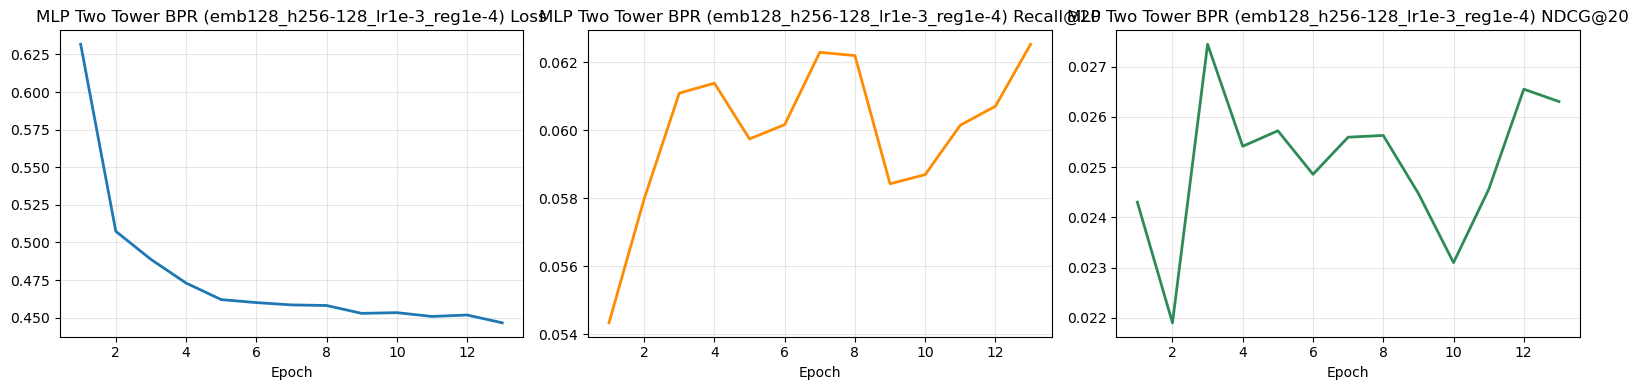

In [35]:
class TwoTowerMLP(nn.Module):
    """MLP-based Two Tower model for ranking recommendation."""

    def __init__(self, n_users: int, n_items: int, embedding_dim: int = 64, hidden_dims=(128, 64)) -> None:
        super().__init__()
        self.n_users = n_users
        self.n_items = n_items
        self.embedding_dim = embedding_dim
        self.hidden_dims = tuple(hidden_dims)

        self.user_embedding = nn.Embedding(n_users, embedding_dim)
        self.item_embedding = nn.Embedding(n_items, embedding_dim)
        self.user_tower = self._build_tower(embedding_dim, self.hidden_dims)
        self.item_tower = self._build_tower(embedding_dim, self.hidden_dims)
        self.prediction = nn.Linear(self.hidden_dims[-1] * 2, 1)
        self._init_weights()

    @staticmethod
    def _build_tower(input_dim: int, hidden_dims) -> nn.Sequential:
        layers = []
        current_dim = input_dim
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(current_dim, hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(0.2))
            current_dim = hidden_dim
        return nn.Sequential(*layers)

    def _init_weights(self) -> None:
        nn.init.normal_(self.user_embedding.weight, std=0.01)
        nn.init.normal_(self.item_embedding.weight, std=0.01)
        for tower in (self.user_tower, self.item_tower):
            for layer in tower:
                if isinstance(layer, nn.Linear):
                    nn.init.xavier_uniform_(layer.weight)
                    nn.init.zeros_(layer.bias)
        nn.init.xavier_uniform_(self.prediction.weight)
        nn.init.zeros_(self.prediction.bias)

    def encode_users(self, users: torch.Tensor) -> torch.Tensor:
        return self.user_tower(self.user_embedding(users))

    def encode_items(self, items: torch.Tensor) -> torch.Tensor:
        return self.item_tower(self.item_embedding(items))

    def forward(self, users: torch.Tensor, items: torch.Tensor) -> torch.Tensor:
        user_repr = self.encode_users(users)
        item_repr = self.encode_items(items)
        combined = torch.cat([user_repr, item_repr], dim=1)
        return self.prediction(combined).squeeze(-1)


MLPTwoTower = TwoTowerMLP

set_global_seed(SEED)
print_section('Training MLP Two Tower BPR')
two_tower_cfg = MODEL_CONFIGS['two_tower_bpr']

# Section-local wrappers keep model construction/training/evaluation consistent with the shared runner.
def build_two_tower_trial(cfg):
    return MLPTwoTower(n_users, n_items, embedding_dim=cfg['embedding_dim'], hidden_dims=cfg['hidden_dims']).to(device)

def train_two_tower_trial(model, cfg, save_path):
    return train_two_tower_with_val(model, train_df, val_df, cfg, save_path)

def evaluate_two_tower_trial(model, eval_df):
    return evaluate_two_tower(model, eval_df, top_k=TOP_K)

two_tower_best = run_training_trials('two_tower_bpr', 'MLP Two Tower BPR', two_tower_cfg, build_two_tower_trial, train_two_tower_trial, evaluate_two_tower_trial)
two_tower_bpr_model = two_tower_best['model']
two_tower_bpr_history = two_tower_best['history']
two_tower_train_time = two_tower_best['train_time']
two_tower_loaded = two_tower_best['loaded']
record_training_summary('MLP Two Tower BPR', two_tower_bpr_history, two_tower_train_time, loaded_from_checkpoint=two_tower_loaded, selected_trial=two_tower_best['trial_name'])
two_tower_bpr_metrics = evaluate_two_tower(two_tower_bpr_model, test_df, top_k=TOP_K)
append_result('MLP Two Tower BPR', two_tower_bpr_metrics)
display(pd.DataFrame([{'Model': 'MLP Two Tower BPR', 'SelectedTrial': two_tower_best['trial_name'], **two_tower_bpr_metrics}]))
plot_history(two_tower_bpr_history, f"MLP Two Tower BPR ({two_tower_best['trial_name']})")


<a id='section-5-lightgcn-baseline'></a>
##### 5. LightGCN - Baseline



Training LightGCN BPR

LightGCN BPR Trial: emb128_l3_lr1e-3_reg1e-4
Epoch 01 | loss=0.6405 | R@20=0.0079 | N@20=0.0033
Epoch 02 | loss=0.6167 | R@20=0.0246 | N@20=0.0120
Epoch 03 | loss=0.5834 | R@20=0.0481 | N@20=0.0225
Epoch 04 | loss=0.5356 | R@20=0.0653 | N@20=0.0297
Epoch 05 | loss=0.4780 | R@20=0.0761 | N@20=0.0337
Epoch 06 | loss=0.4159 | R@20=0.0817 | N@20=0.0362
Epoch 07 | loss=0.3553 | R@20=0.0846 | N@20=0.0376
Epoch 08 | loss=0.3027 | R@20=0.0874 | N@20=0.0386
Epoch 09 | loss=0.2563 | R@20=0.0896 | N@20=0.0395
Epoch 10 | loss=0.2173 | R@20=0.0919 | N@20=0.0405
Epoch 11 | loss=0.1842 | R@20=0.0931 | N@20=0.0411
Epoch 12 | loss=0.1602 | R@20=0.0939 | N@20=0.0414
Epoch 13 | loss=0.1381 | R@20=0.0950 | N@20=0.0419
Epoch 14 | loss=0.1211 | R@20=0.0952 | N@20=0.0420
Epoch 15 | loss=0.1055 | R@20=0.0964 | N@20=0.0425
Epoch 16 | loss=0.0941 | R@20=0.0973 | N@20=0.0428
Epoch 17 | loss=0.0840 | R@20=0.0982 | N@20=0.0431
Epoch 18 | loss=0.0752 | R@20=0.0983 | N@20=0.0432
Epoch 19 | lo

,Model,SelectedTrial,NDCG@20,Recall@20,Precision@20,MRR,num_users
0,LightGCN BPR,emb128_l3_lr1e-3_reg1e-4,0.03178,0.070845,0.004436,0.023053,15093


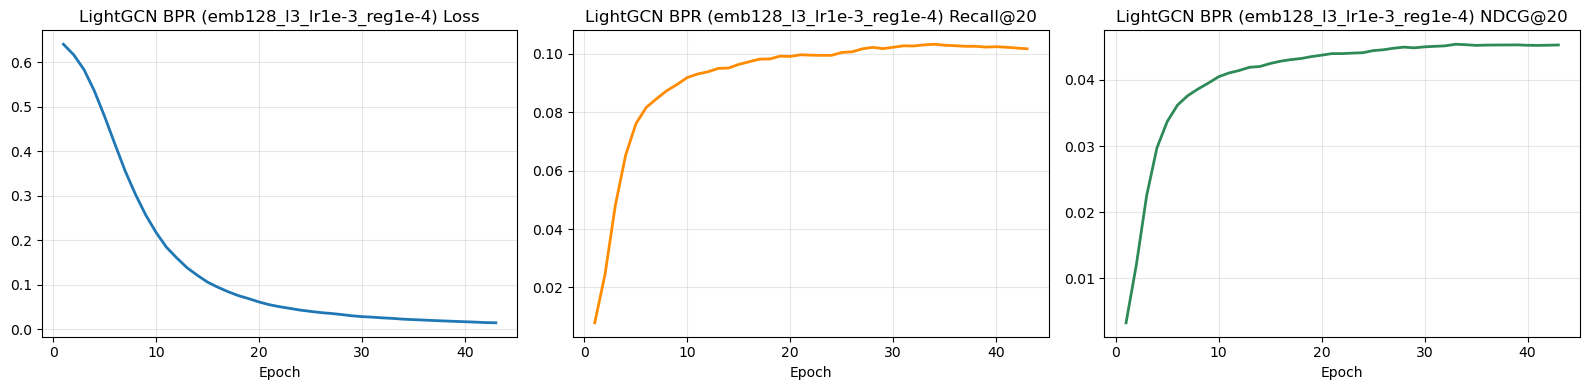

In [24]:
class LightGCN(nn.Module):
    """LightGCN with BPR ranking loss and a rating-style scoring head."""

    def __init__(
        self,
        n_users: int,
        n_items: int,
        embedding_dim: int = 64,
        n_layers: int = 3,
        use_rating_bias: bool = True,
        rating_range=(1.0, 5.0),
    ) -> None:
        super().__init__()
        self.n_users = n_users
        self.n_items = n_items
        self.embedding_dim = embedding_dim
        self.n_layers = n_layers
        self.use_rating_bias = use_rating_bias
        self.rating_range = rating_range
        self.f = nn.Sigmoid()

        self.embedding_user = nn.Embedding(n_users, embedding_dim)
        self.embedding_item = nn.Embedding(n_items, embedding_dim)
        if self.use_rating_bias:
            self.user_bias = nn.Embedding(n_users, 1)
            self.item_bias = nn.Embedding(n_items, 1)
            self.global_bias = nn.Parameter(torch.zeros(1))
        self._init_weights()

    def _init_weights(self) -> None:
        nn.init.normal_(self.embedding_user.weight, std=0.1)
        nn.init.normal_(self.embedding_item.weight, std=0.1)
        if self.use_rating_bias:
            nn.init.zeros_(self.user_bias.weight)
            nn.init.zeros_(self.item_bias.weight)

    def computer(self, adj_mat: torch.Tensor):
        users_emb = self.embedding_user.weight
        items_emb = self.embedding_item.weight
        all_emb = torch.cat([users_emb, items_emb], dim=0)
        embs = [all_emb]
        for _ in range(self.n_layers):
            all_emb = torch.sparse.mm(adj_mat, all_emb)
            embs.append(all_emb)
        embs = torch.stack(embs, dim=1)
        light_out = torch.mean(embs, dim=1)
        users, items = torch.split(light_out, [self.n_users, self.n_items])
        return users, items

    def getUsersRating(self, users: torch.Tensor, adj_mat: torch.Tensor) -> torch.Tensor:
        all_users, all_items = self.computer(adj_mat)
        users_emb = all_users[users.long()]
        scores = torch.matmul(users_emb, all_items.t())
        return self.f(scores)

    def getEmbedding(self, users, pos_items, neg_items, adj_mat):
        all_users, all_items = self.computer(adj_mat)
        users_emb = all_users[users.long()]
        pos_emb = all_items[pos_items.long()]
        neg_emb = all_items[neg_items.long()]
        users_emb_ego = self.embedding_user(users.long())
        pos_emb_ego = self.embedding_item(pos_items.long())
        neg_emb_ego = self.embedding_item(neg_items.long())
        return users_emb, pos_emb, neg_emb, users_emb_ego, pos_emb_ego, neg_emb_ego

    def bpr_loss(self, users: torch.Tensor, pos: torch.Tensor, neg: torch.Tensor, adj_mat: torch.Tensor):
        users_emb, pos_emb, neg_emb, user_emb0, pos_emb0, neg_emb0 = self.getEmbedding(users, pos, neg, adj_mat)
        reg_loss = 0.5 * (
            user_emb0.norm(2).pow(2)
            + pos_emb0.norm(2).pow(2)
            + neg_emb0.norm(2).pow(2)
        ) / float(len(users))
        pos_scores = torch.sum(users_emb * pos_emb, dim=1)
        neg_scores = torch.sum(users_emb * neg_emb, dim=1)
        loss = torch.mean(F.softplus(neg_scores - pos_scores))
        return loss, reg_loss

    def _raw_scores_from_embeddings(self, users, items, user_embeddings, item_embeddings):
        users_emb = user_embeddings[users.long()]
        items_emb = item_embeddings[items.long()]
        return torch.sum(users_emb * items_emb, dim=1)

    def _apply_rating_head(self, raw_scores, users, items, apply_range: bool = True):
        rating_scores = raw_scores
        if self.use_rating_bias:
            rating_scores = rating_scores + self.user_bias(users.long()).squeeze(-1)
            rating_scores = rating_scores + self.item_bias(items.long()).squeeze(-1)
            rating_scores = rating_scores + self.global_bias
        if apply_range:
            rating_min, rating_max = self.rating_range
            rating_scores = rating_min + (rating_max - rating_min) * self.f(rating_scores)
        return rating_scores

    def forward(self, users: torch.Tensor, items: torch.Tensor, adj_mat: torch.Tensor) -> torch.Tensor:
        all_users, all_items = self.computer(adj_mat)
        return self._raw_scores_from_embeddings(users, items, all_users, all_items)

    def predict(self, users, items, user_embeddings=None, item_embeddings=None, adj_mat=None, apply_range: bool = True):
        if user_embeddings is None or item_embeddings is None:
            if adj_mat is None:
                raise ValueError('adj_mat is required when embeddings are not provided')
            user_embeddings, item_embeddings = self.computer(adj_mat)
        raw_scores = self._raw_scores_from_embeddings(users, items, user_embeddings, item_embeddings)
        return self._apply_rating_head(raw_scores, users, items, apply_range=apply_range)

    def predict_rating(self, users, items, adj_mat, apply_range: bool = True):
        return self.predict(users, items, adj_mat=adj_mat, apply_range=apply_range)


set_global_seed(SEED)
print_section('Training LightGCN BPR')
lightgcn_cfg = MODEL_CONFIGS['lightgcn_bpr']

# Baseline graph model: user-item graph propagation trained with BPR.
def build_lightgcn_trial(cfg):
    return LightGCN(n_users, n_items, embedding_dim=cfg['embedding_dim'], n_layers=cfg['n_layers']).to(device)

def train_lightgcn_trial(model, cfg, save_path):
    return train_lightgcn_with_val(model, norm_adj_tensor, train_df, val_df, cfg, save_path)

def evaluate_lightgcn_trial(model, eval_df):
    return evaluate_lightgcn(model, norm_adj_tensor, eval_df, top_k=TOP_K)

lightgcn_best = run_training_trials('lightgcn_bpr', 'LightGCN BPR', lightgcn_cfg, build_lightgcn_trial, train_lightgcn_trial, evaluate_lightgcn_trial)
lightgcn_bpr_model = lightgcn_best['model']
lightgcn_bpr_history = lightgcn_best['history']
lightgcn_train_time = lightgcn_best['train_time']
lightgcn_loaded = lightgcn_best['loaded']
record_training_summary('LightGCN BPR', lightgcn_bpr_history, lightgcn_train_time, loaded_from_checkpoint=lightgcn_loaded, selected_trial=lightgcn_best['trial_name'])
lightgcn_bpr_metrics = evaluate_lightgcn(lightgcn_bpr_model, norm_adj_tensor, test_df, top_k=TOP_K)
append_result('LightGCN BPR', lightgcn_bpr_metrics)
display(pd.DataFrame([{'Model': 'LightGCN BPR', 'SelectedTrial': lightgcn_best['trial_name'], **lightgcn_bpr_metrics}]))
plot_history(lightgcn_bpr_history, f"LightGCN BPR ({lightgcn_best['trial_name']})")


<a id='section-6-ranking-models'></a>
##### 6. Other Ranking Models


<a id='section-6-lightgcl'></a>
##### 6.1 LightGCL


In [25]:
# LightGCL uses a normalized user-item matrix to build its SVD contrastive view.
def build_normalized_R(train_df: pd.DataFrame, n_users: int, n_items: int) -> sp.csr_matrix:
    rows = train_df['user_idx'].to_numpy(dtype=np.int64)
    cols = train_df['item_idx'].to_numpy(dtype=np.int64)
    vals = np.ones(len(train_df), dtype=np.float32)
    R = sp.coo_matrix((vals, (rows, cols)), shape=(n_users, n_items)).tocsr()
    user_degree = np.asarray(R.sum(axis=1)).reshape(-1)
    item_degree = np.asarray(R.sum(axis=0)).reshape(-1)
    d_u = np.zeros_like(user_degree, dtype=np.float32)
    d_i = np.zeros_like(item_degree, dtype=np.float32)
    np.power(user_degree, -0.5, out=d_u, where=user_degree > 0)
    np.power(item_degree, -0.5, out=d_i, where=item_degree > 0)
    D_u = sp.diags(d_u)
    D_i = sp.diags(d_i)
    return D_u @ R @ D_i


# BPR dataset samples one unobserved negative item for each observed user-item pair.
# LightGCL combines graph propagation with an SVD-based contrastive signal.
class LightGCLBPRDataset(Dataset):
    def __init__(self, train_df, n_items):
        self.users = train_df['user_idx'].values.astype(np.int64)
        self.pos = train_df['item_idx'].values.astype(np.int64)
        self.n_items = n_items
        self.user_pos = defaultdict(set)
        for u, i in zip(self.users, self.pos):
            self.user_pos[u].add(i)

    def __len__(self):
        return len(self.users)

    def __getitem__(self, idx):
        u = int(self.users[idx])
        p = int(self.pos[idx])
        while True:
            n = np.random.randint(self.n_items)
            if n not in self.user_pos[u]:
                return u, p, n


class LightGCL(nn.Module):
    def __init__(self, n_users, n_items, U_hat, V_hat, d=64, n_layers=2, dropout=0.0):
        super().__init__()
        self.n_users = n_users
        self.n_items = n_items
        self.n_layers = n_layers
        self.dropout = dropout

        self.E_u_0 = nn.Parameter(torch.empty(n_users, d))
        self.E_i_0 = nn.Parameter(torch.empty(n_items, d))
        nn.init.xavier_uniform_(self.E_u_0)
        nn.init.xavier_uniform_(self.E_i_0)

        self.register_buffer('U_hat', U_hat)
        self.register_buffer('V_hat', V_hat)

    def edge_drop(self, A_hat):
        if self.dropout <= 0 or not self.training:
            return A_hat
        idx = A_hat._indices()
        val = A_hat._values()
        keep = torch.rand_like(val) > self.dropout
        idx = idx[:, keep]
        val = val[keep] / (1 - self.dropout)
        return torch.sparse_coo_tensor(idx, val, A_hat.shape).coalesce()

    def propagate(self, A_hat):
        A = self.edge_drop(A_hat)

        E_u_list = [self.E_u_0]
        E_i_list = [self.E_i_0]
        G_u_list = [self.E_u_0]
        G_i_list = [self.E_i_0]

        for _ in range(self.n_layers):
            E_prev = torch.cat([E_u_list[-1], E_i_list[-1]], dim=0)
            E_next = torch.sparse.mm(A, E_prev)
            E_u_l, E_i_l = torch.split(E_next, [self.n_users, self.n_items], dim=0)
            E_u_list.append(E_u_l)
            E_i_list.append(E_i_l)

            G_u = self.U_hat @ (self.V_hat.t() @ E_i_list[-2])
            G_i = self.V_hat @ (self.U_hat.t() @ E_u_list[-2])
            G_u_list.append(G_u)
            G_i_list.append(G_i)

        E_u = torch.stack(E_u_list, dim=1).mean(dim=1)
        E_i = torch.stack(E_i_list, dim=1).mean(dim=1)
        return E_u, E_i, G_u_list, G_i_list, E_u_list, E_i_list

    def score(self, users, items, E_u, E_i):
        return (E_u[users] * E_i[items]).sum(dim=-1)


def info_nce(z1, z2, all_z2, tau):
    z1 = F.normalize(z1, dim=-1)
    z2 = F.normalize(z2, dim=-1)
    all_z2 = F.normalize(all_z2, dim=-1)
    pos = (z1 * z2).sum(-1) / tau
    logits = z1 @ all_z2.t() / tau
    return -(pos - torch.logsumexp(logits, dim=-1)).mean()


# Total loss = BPR ranking loss + contrastive regularization + embedding L2 penalty.
def lightgcl_loss(model, A_hat, users, pos, neg, tau=0.5, lam_cl=0.2, lam_reg=1e-7):
    E_u, E_i, G_u_list, G_i_list, E_u_list, E_i_list = model.propagate(A_hat)

    s_pos = model.score(users, pos, E_u, E_i)
    s_neg = model.score(users, neg, E_u, E_i)
    bpr = -F.logsigmoid(s_pos - s_neg).mean()

    u_uniq = torch.unique(users)
    i_uniq = torch.unique(torch.cat([pos, neg]))

    cl = 0.0
    for l in range(1, model.n_layers + 1):
        cl = cl + info_nce(E_u_list[l][u_uniq], G_u_list[l][u_uniq], G_u_list[l][u_uniq], tau)
        cl = cl + info_nce(G_u_list[l][u_uniq], E_u_list[l][u_uniq], E_u_list[l][u_uniq], tau)
        cl = cl + info_nce(E_i_list[l][i_uniq], G_i_list[l][i_uniq], G_i_list[l][i_uniq], tau)
        cl = cl + info_nce(G_i_list[l][i_uniq], E_i_list[l][i_uniq], E_i_list[l][i_uniq], tau)
    cl = cl / (4 * model.n_layers)

    reg = (
        model.E_u_0[users].pow(2).sum()
        + model.E_i_0[pos].pow(2).sum()
        + model.E_i_0[neg].pow(2).sum()
    ) / users.size(0)

    loss = bpr + lam_cl * cl + lam_reg * reg
    return loss, bpr.item(), cl.item()



Training LightGCL

LightGCL Trial: fixed_n2_r5_tau05_cl02
Epoch 01 | loss=2.2269 | R@20=0.0384 | N@20=0.0168
Epoch 02 | loss=2.2178 | R@20=0.0587 | N@20=0.0260
Epoch 03 | loss=2.2126 | R@20=0.0606 | N@20=0.0265
Epoch 04 | loss=2.2052 | R@20=0.0599 | N@20=0.0261
Epoch 05 | loss=2.1942 | R@20=0.0606 | N@20=0.0262
Epoch 06 | loss=2.1759 | R@20=0.0607 | N@20=0.0262
Epoch 07 | loss=2.1500 | R@20=0.0611 | N@20=0.0264
Epoch 08 | loss=2.1177 | R@20=0.0607 | N@20=0.0263
Epoch 09 | loss=2.0842 | R@20=0.0602 | N@20=0.0262
Epoch 10 | loss=2.0511 | R@20=0.0605 | N@20=0.0265
Epoch 11 | loss=2.0198 | R@20=0.0610 | N@20=0.0268
Epoch 12 | loss=1.9898 | R@20=0.0624 | N@20=0.0273
Epoch 13 | loss=1.9631 | R@20=0.0625 | N@20=0.0274
Epoch 14 | loss=1.9418 | R@20=0.0630 | N@20=0.0275
Epoch 15 | loss=1.9191 | R@20=0.0642 | N@20=0.0280
Epoch 16 | loss=1.8983 | R@20=0.0650 | N@20=0.0282
Epoch 17 | loss=1.8806 | R@20=0.0664 | N@20=0.0289
Epoch 18 | loss=1.8640 | R@20=0.0665 | N@20=0.0290
Epoch 19 | loss=1.8457 

,Model,SelectedTrial,NDCG@20,Recall@20,Precision@20,MRR,num_users
0,LightGCL,fixed_n2_r5_tau05_cl02,0.031511,0.067309,0.004191,0.023749,15093


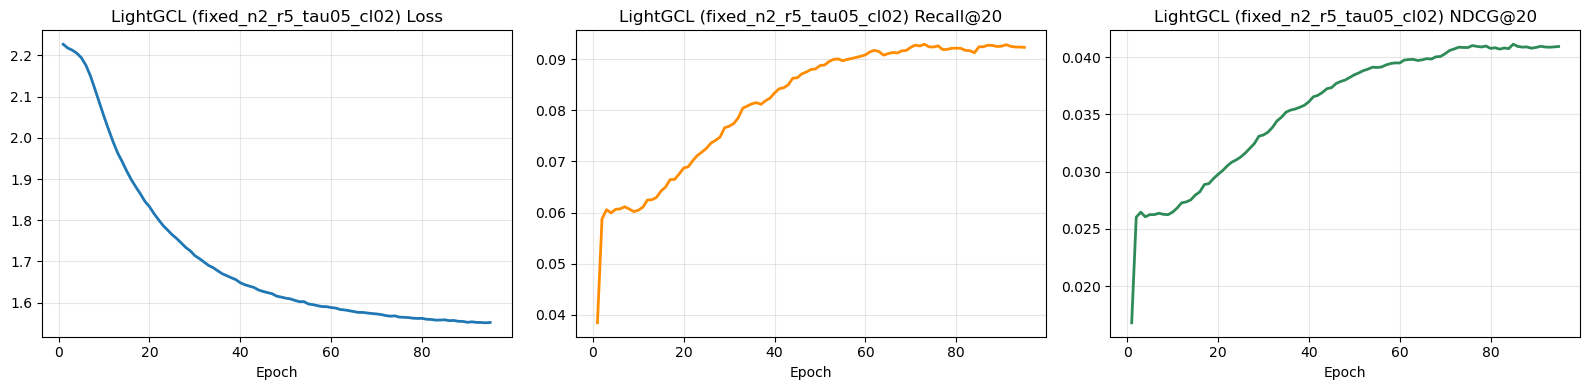

In [26]:
set_global_seed(SEED)
print_section('Training LightGCL')

def evaluate_lightgcl_metrics(model, A_hat, eval_df, top_k=TOP_K):
    model.eval()
    with torch.no_grad():
        E_u, E_i, *_ = model.propagate(A_hat)
    return compute_metrics_from_score_fn(lambda user_idx: E_u[user_idx] @ E_i.t(), eval_df, user_positive_items, top_k=top_k)

def train_lightgcl_with_val(model, A_hat, loader, val_df, cfg, save_path):
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg['lr'])
    best_ndcg, best_recall, patience_counter = -float('inf'), -float('inf'), 0
    history = []
    for epoch in range(EPOCHS):
        model.train()
        total_loss, n_batches = 0.0, 0
        for users, pos, neg in loader:
            users, pos, neg = users.to(device), pos.to(device), neg.to(device)
            optimizer.zero_grad()
            loss, _, _ = lightgcl_loss(model, A_hat, users, pos, neg, tau=cfg['tau'], lam_cl=cfg['lam_cl'], lam_reg=cfg['lam_reg'])
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            n_batches += 1
        train_loss = total_loss / max(1, n_batches)
        val_metrics = evaluate_lightgcl_metrics(model, A_hat, val_df, top_k=TOP_K)
        val_ndcg, val_recall = val_metrics[f'NDCG@{TOP_K}'], val_metrics[f'Recall@{TOP_K}']
        history.append({'epoch': epoch + 1, 'train_loss': train_loss, f'val_ndcg@{TOP_K}': val_ndcg, f'val_recall@{TOP_K}': val_recall})
        print(f"Epoch {epoch+1:02d} | loss={train_loss:.4f} | R@{TOP_K}={val_recall:.4f} | N@{TOP_K}={val_ndcg:.4f}")
        if val_ndcg > best_ndcg or (val_ndcg == best_ndcg and val_recall > best_recall):
            best_ndcg, best_recall, patience_counter = val_ndcg, val_recall, 0
            torch.save(model.state_dict(), save_path)
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print('Early stopping triggered.')
                break
    return history

lightgcl_cfg = MODEL_CONFIGS['lightgcl']
normalized_R = build_normalized_R(train_df, n_users, n_items)
# Cache SVD factors so repeated trials with the same rank do not recompute them.
lightgcl_factor_cache = {}

def get_lightgcl_factors(cfg):
    svd_rank = min(int(cfg['svd_rank']), max(1, min(normalized_R.shape) - 1))
    if svd_rank not in lightgcl_factor_cache:
        U_hat_np, s_vals, Vt_hat_np = svds(normalized_R.astype(np.float32), k=svd_rank)
        sort_idx = np.argsort(-s_vals)
        lightgcl_factor_cache[svd_rank] = (
            torch.tensor(U_hat_np[:, sort_idx], dtype=torch.float32, device=device),
            torch.tensor(Vt_hat_np[sort_idx, :].T, dtype=torch.float32, device=device),
        )
    return lightgcl_factor_cache[svd_rank]

# Build the chosen LightGCL architecture using the cached SVD factors.
def build_lightgcl_trial(cfg):
    U_hat, V_hat = get_lightgcl_factors(cfg)
    return LightGCL(n_users, n_items, U_hat, V_hat, d=cfg['embedding_dim'], n_layers=cfg['n_layers'], dropout=cfg['dropout']).to(device)

def train_lightgcl_trial(model, cfg, save_path):
    loader = DataLoader(LightGCLBPRDataset(train_df, n_items), batch_size=cfg['batch_size'], shuffle=True, num_workers=0)
    return train_lightgcl_with_val(model, norm_adj_tensor, loader, val_df, cfg, save_path)

def evaluate_lightgcl_trial(model, eval_df):
    return evaluate_lightgcl_metrics(model, norm_adj_tensor, eval_df, top_k=TOP_K)

lightgcl_best = run_training_trials('lightgcl', 'LightGCL', lightgcl_cfg, build_lightgcl_trial, train_lightgcl_trial, evaluate_lightgcl_trial)
lightgcl_model = lightgcl_best['model']
lightgcl_history = lightgcl_best['history']
lightgcl_train_time = lightgcl_best['train_time']
lightgcl_loaded = lightgcl_best['loaded']
record_training_summary('LightGCL', lightgcl_history, lightgcl_train_time, loaded_from_checkpoint=lightgcl_loaded, selected_trial=lightgcl_best['trial_name'])
lightgcl_metrics = evaluate_lightgcl_metrics(lightgcl_model, norm_adj_tensor, test_df, top_k=TOP_K)
append_result('LightGCL', lightgcl_metrics)
display(pd.DataFrame([{'Model': 'LightGCL', 'SelectedTrial': lightgcl_best['trial_name'], **lightgcl_metrics}]))
plot_history(lightgcl_history, f"LightGCL ({lightgcl_best['trial_name']})")


<a id='section-6-gatv2'></a>
##### 6.2 GATv2



Training GATv2

GATv2 Trial: emb128_l2_h4_lr5e-4_drop0
Epoch 01 | loss=0.6725 | R@20=0.0205 | N@20=0.0095
Epoch 02 | loss=0.4971 | R@20=0.0461 | N@20=0.0171
Epoch 03 | loss=0.3906 | R@20=0.0497 | N@20=0.0192
Epoch 04 | loss=0.3700 | R@20=0.0457 | N@20=0.0184
Epoch 05 | loss=0.3544 | R@20=0.0475 | N@20=0.0199
Epoch 06 | loss=0.3523 | R@20=0.0502 | N@20=0.0224
Epoch 07 | loss=0.3481 | R@20=0.0551 | N@20=0.0236
Epoch 08 | loss=0.3464 | R@20=0.0540 | N@20=0.0221
Epoch 09 | loss=0.3422 | R@20=0.0513 | N@20=0.0209
Epoch 10 | loss=0.3412 | R@20=0.0511 | N@20=0.0207
Epoch 11 | loss=0.3347 | R@20=0.0520 | N@20=0.0219
Epoch 12 | loss=0.3360 | R@20=0.0534 | N@20=0.0239
Epoch 13 | loss=0.3287 | R@20=0.0548 | N@20=0.0236
Epoch 14 | loss=0.3146 | R@20=0.0530 | N@20=0.0229
Epoch 15 | loss=0.2991 | R@20=0.0499 | N@20=0.0196
Epoch 16 | loss=0.2888 | R@20=0.0502 | N@20=0.0194
Epoch 17 | loss=0.2780 | R@20=0.0429 | N@20=0.0182
Epoch 18 | loss=0.2652 | R@20=0.0417 | N@20=0.0167
Epoch 19 | loss=0.2608 | R

,Model,SelectedTrial,NDCG@20,Recall@20,Precision@20,MRR,num_users
0,GATv2,emb128_l2_h4_lr5e-4_drop0,0.022307,0.045768,0.002885,0.017188,15093


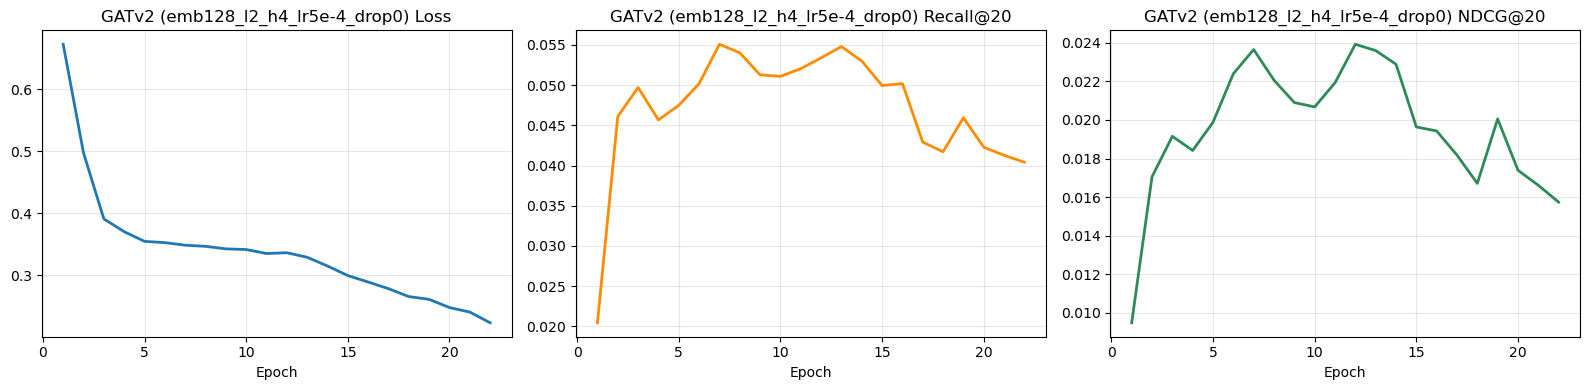

In [34]:
set_global_seed(SEED)
print_section('Training GATv2')

if not HAS_TORCH_GEOMETRIC:
    print('Skipping GATv2 because torch_geometric is not installed.')
    print(GATV2_IMPORT_ERROR)
    gat_metrics = None
    gat_history = []
    record_training_summary('GATv2', gat_history, 0.0, skipped=True)
else:
    # Convert the training interactions into a bidirectional PyG edge_index.
    def build_edge_index_from_train_df(train_df, n_users, n_items):
        user_indices = train_df['user_idx'].to_numpy(dtype=np.int64)
        item_indices = train_df['item_idx'].to_numpy(dtype=np.int64)
        row = np.concatenate([user_indices, item_indices + n_users])
        col = np.concatenate([item_indices + n_users, user_indices])
        return torch.LongTensor(np.vstack([row, col])).to(device)

    class GATOriginalBPRDataset(Dataset):
        def __init__(self, train_df, n_items):
            self.users = train_df['user_idx'].values.astype(np.int64)
            self.pos_items = train_df['item_idx'].values.astype(np.int64)
            self.n_items = n_items
            self.user_pos = defaultdict(set)
            for u, i in zip(self.users, self.pos_items):
                self.user_pos[u].add(i)
        def __len__(self):
            return len(self.users)
        def __getitem__(self, idx):
            u = int(self.users[idx])
            pos = int(self.pos_items[idx])
            while True:
                neg = np.random.randint(self.n_items)
                if neg not in self.user_pos[u]:
                    break
            return u, pos, neg

    # GATv2 collaborative filtering model over the bipartite user-item graph.
    class GATCF(nn.Module):
        def __init__(self, n_users, n_items, embedding_dim=64, n_layers=2, n_heads=4, dropout=0.0):
            super().__init__()
            self.n_users = n_users
            self.n_items = n_items
            self.user_emb = nn.Embedding(n_users, embedding_dim)
            self.item_emb = nn.Embedding(n_items, embedding_dim)
            nn.init.normal_(self.user_emb.weight, std=0.1)
            nn.init.normal_(self.item_emb.weight, std=0.1)
            self.gat_layers = nn.ModuleList([
                GATv2Conv(embedding_dim, embedding_dim, heads=n_heads, concat=False, dropout=dropout, add_self_loops=True)
                for _ in range(n_layers)
            ])
        def propagate(self, edge_index):
            x = torch.cat([self.user_emb.weight, self.item_emb.weight], dim=0)
            for i, layer in enumerate(self.gat_layers):
                x = layer(x, edge_index)
                if i < len(self.gat_layers) - 1:
                    x = F.elu(x)
            return torch.split(x, [self.n_users, self.n_items], dim=0)
        def bpr_loss(self, users, pos, neg, edge_index, l2_reg=1e-4):
            users_out, items_out = self.propagate(edge_index)
            u_e, p_e, n_e = users_out[users], items_out[pos], items_out[neg]
            bpr = -F.logsigmoid((u_e * p_e).sum(-1) - (u_e * n_e).sum(-1)).mean()
            reg = (self.user_emb(users).pow(2).sum() + self.item_emb(pos).pow(2).sum() + self.item_emb(neg).pow(2).sum()) / users.size(0)
            return bpr + l2_reg * 0.5 * reg, bpr.item()

    def evaluate_gat_metrics(model, edge_index, eval_df, top_k=TOP_K):
        model.eval()
        with torch.no_grad():
            users_out, items_out = model.propagate(edge_index)
        return compute_metrics_from_score_fn(lambda user_idx: users_out[user_idx] @ items_out.T, eval_df, user_positive_items, top_k=top_k)

    # GATv2 training mirrors the other BPR ranking models and stops on validation NDCG.
    def train_gat_with_val(model, edge_index, loader, val_df, cfg, save_path):
        optimizer = torch.optim.Adam(model.parameters(), lr=cfg['lr'])
        best_ndcg, best_recall, patience_counter = -float('inf'), -float('inf'), 0
        history = []
        for epoch in range(EPOCHS):
            model.train()
            total_loss, n_batches = 0.0, 0
            for users, pos, neg in loader:
                users, pos, neg = users.to(device), pos.to(device), neg.to(device)
                optimizer.zero_grad()
                loss, _ = model.bpr_loss(users, pos, neg, edge_index, l2_reg=cfg['l2_reg'])
                loss.backward()
                optimizer.step()
                total_loss += loss.item()
                n_batches += 1
            train_loss = total_loss / max(1, n_batches)
            val_metrics = evaluate_gat_metrics(model, edge_index, val_df, top_k=TOP_K)
            val_ndcg, val_recall = val_metrics[f'NDCG@{TOP_K}'], val_metrics[f'Recall@{TOP_K}']
            history.append({'epoch': epoch + 1, 'train_loss': train_loss, f'val_ndcg@{TOP_K}': val_ndcg, f'val_recall@{TOP_K}': val_recall})
            print(f"Epoch {epoch+1:02d} | loss={train_loss:.4f} | R@{TOP_K}={val_recall:.4f} | N@{TOP_K}={val_ndcg:.4f}")
            if val_ndcg > best_ndcg or (val_ndcg == best_ndcg and val_recall > best_recall):
                best_ndcg, best_recall, patience_counter = val_ndcg, val_recall, 0
                torch.save(model.state_dict(), save_path)
            else:
                patience_counter += 1
                if patience_counter >= PATIENCE:
                    print('Early stopping triggered.')
                    break
        return history

    gat_cfg = MODEL_CONFIGS['gatv2']
    edge_index = build_edge_index_from_train_df(train_df, n_users, n_items)

    def build_gat_trial(cfg):
        return GATCF(n_users, n_items, embedding_dim=cfg['embedding_dim'], n_layers=cfg['n_layers'], n_heads=cfg['n_heads'], dropout=cfg['dropout']).to(device)

    def train_gat_trial(model, cfg, save_path):
        loader = DataLoader(GATOriginalBPRDataset(train_df, n_items), batch_size=cfg['batch_size'], shuffle=True, num_workers=0)
        return train_gat_with_val(model, edge_index, loader, val_df, cfg, save_path)

    def evaluate_gat_trial(model, eval_df):
        return evaluate_gat_metrics(model, edge_index, eval_df, top_k=TOP_K)

    gat_best = run_training_trials('gatv2', 'GATv2', gat_cfg, build_gat_trial, train_gat_trial, evaluate_gat_trial)
    gat_model = gat_best['model']
    gat_history = gat_best['history']
    gat_train_time = gat_best['train_time']
    gat_loaded = gat_best['loaded']
    record_training_summary('GATv2', gat_history, gat_train_time, loaded_from_checkpoint=gat_loaded, selected_trial=gat_best['trial_name'])
    gat_metrics = evaluate_gat_metrics(gat_model, edge_index, test_df, top_k=TOP_K)
    append_result('GATv2', gat_metrics)
    display(pd.DataFrame([{'Model': 'GATv2', 'SelectedTrial': gat_best['trial_name'], **gat_metrics}]))
    plot_history(gat_history, f"GATv2 ({gat_best['trial_name']})")


<a id='section-6-graphsage'></a>
##### 6.3 GraphSAGE


In [32]:
# One GraphSAGE layer concatenates each node with its normalized neighborhood aggregate.
class GraphSAGELayer(nn.Module):
    def __init__(self, in_dim, out_dim, dropout=0.2):
        super(GraphSAGELayer, self).__init__()
        self.linear = nn.Linear(in_dim * 2, out_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, norm_adj):
        neigh = torch.sparse.mm(norm_adj, x)
        out = torch.cat([x, neigh], dim=1)
        out = self.linear(out)
        out = F.relu(out)
        out = self.dropout(out)
        return out


# GraphSAGE recommender keeps embedding and hidden dimensions equal so layer outputs can be averaged.
class GraphSAGERecommender(nn.Module):
    """
    GraphSAGE-style recommender for top-K ranking on a user-item bipartite graph.

    The model returns raw relevance scores instead of explicit rating predictions.
    This is intentional for ranking with BPR loss.
    """
    def __init__(self, n_users, n_items, embedding_dim=64, hidden_dim=64, n_layers=2, dropout=0.2):
        super(GraphSAGERecommender, self).__init__()
        self.n_users = n_users
        self.n_items = n_items
        self.embedding_dim = embedding_dim

        self.user_embedding = nn.Embedding(n_users, embedding_dim)
        self.item_embedding = nn.Embedding(n_items, embedding_dim)

        self.layers = nn.ModuleList()
        input_dim = embedding_dim
        for _ in range(n_layers):
            self.layers.append(GraphSAGELayer(input_dim, hidden_dim, dropout=dropout))
            input_dim = hidden_dim

        # Bias terms are useful for recommendation ranking, but scores stay unbounded.
        self.user_bias = nn.Embedding(n_users, 1)
        self.item_bias = nn.Embedding(n_items, 1)
        self.global_bias = nn.Parameter(torch.zeros(1))

        self._init_weights()

    def _init_weights(self):
        nn.init.normal_(self.user_embedding.weight, std=0.1)
        nn.init.normal_(self.item_embedding.weight, std=0.1)
        nn.init.zeros_(self.user_bias.weight)
        nn.init.zeros_(self.item_bias.weight)

    def get_all_embeddings(self, norm_adj):
        x = torch.cat([self.user_embedding.weight, self.item_embedding.weight], dim=0)
        representations = [x]

        for layer in self.layers:
            x = layer(x, norm_adj)
            representations.append(x)

        # Average initial and propagated embeddings.
        final_x = torch.stack(representations, dim=0).mean(dim=0)
        user_x = final_x[:self.n_users]
        item_x = final_x[self.n_users:]
        return user_x, item_x

    def score_pairs(self, users, items, norm_adj):
        user_x, item_x = self.get_all_embeddings(norm_adj)
        user_vec = user_x[users]
        item_vec = item_x[items]

        scores = (user_vec * item_vec).sum(dim=1)
        scores = scores + self.user_bias(users).squeeze(-1) + self.item_bias(items).squeeze(-1) + self.global_bias
        return scores

    def score_pairs_from_embeddings(self, user_x, item_x, users, items):
        user_vec = user_x[users]
        item_vec = item_x[items]
        scores = (user_vec * item_vec).sum(dim=1)
        scores = scores + self.user_bias(users).squeeze(-1) + self.item_bias(items).squeeze(-1) + self.global_bias
        return scores

    def forward(self, users, items, norm_adj):
        return self.score_pairs(users, items, norm_adj)



Training GraphSAGE

GraphSAGE Trial: emb256_h256_l2_drop02_lr5e-4
Epoch 01 | loss=0.5910 | R@20=0.0584 | N@20=0.0254
Epoch 02 | loss=0.4972 | R@20=0.0609 | N@20=0.0258
Epoch 03 | loss=0.4740 | R@20=0.0599 | N@20=0.0244
Epoch 04 | loss=0.4523 | R@20=0.0623 | N@20=0.0256
Epoch 05 | loss=0.4423 | R@20=0.0582 | N@20=0.0244
Epoch 06 | loss=0.4272 | R@20=0.0588 | N@20=0.0228
Epoch 07 | loss=0.4161 | R@20=0.0615 | N@20=0.0265
Epoch 08 | loss=0.4117 | R@20=0.0550 | N@20=0.0231
Epoch 09 | loss=0.3974 | R@20=0.0585 | N@20=0.0273
Epoch 10 | loss=0.3857 | R@20=0.0563 | N@20=0.0243
Epoch 11 | loss=0.3544 | R@20=0.0537 | N@20=0.0224
Epoch 12 | loss=0.3433 | R@20=0.0502 | N@20=0.0196
Epoch 13 | loss=0.3262 | R@20=0.0528 | N@20=0.0232
Epoch 14 | loss=0.3062 | R@20=0.0509 | N@20=0.0210
Epoch 15 | loss=0.2724 | R@20=0.0549 | N@20=0.0214
Epoch 16 | loss=0.2302 | R@20=0.0486 | N@20=0.0198
Epoch 17 | loss=0.1938 | R@20=0.0370 | N@20=0.0133
Epoch 18 | loss=0.1652 | R@20=0.0449 | N@20=0.0179
Epoch 19 | loss

,Model,SelectedTrial,NDCG@20,Recall@20,Precision@20,MRR,num_users
0,GraphSAGE,emb256_h256_l2_drop02_lr5e-4,0.027151,0.050161,0.003111,0.022901,15093


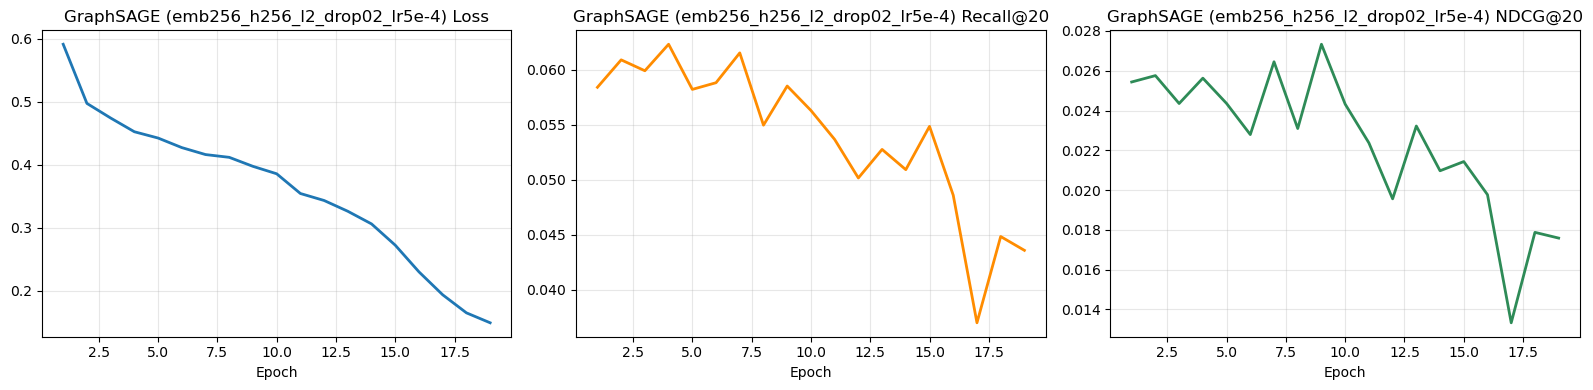

In [33]:
set_global_seed(SEED)
print_section('Training GraphSAGE')

def graphsage_bpr_loss(pos_scores, neg_scores):
    return -torch.log(torch.sigmoid(pos_scores - neg_scores) + 1e-8).mean()

# Sample BPR triples on the fly so each epoch sees fresh negative items.
def train_graphsage_bpr_epoch(model, norm_adj, train_df, user_positive_items, num_items, optimizer, batch_size, device, reg_weight=1e-5):
    model.train()
    total_loss = 0.0
    num_steps = int(np.ceil(len(train_df) / batch_size))
    for _ in range(num_steps):
        users, pos_items, neg_items = sample_bpr_batch(train_df, user_positive_items, num_items, batch_size)
        users, pos_items, neg_items = users.to(device), pos_items.to(device), neg_items.to(device)
        pos_scores = model(users, pos_items, norm_adj)
        neg_scores = model(users, neg_items, norm_adj)
        loss = graphsage_bpr_loss(pos_scores, neg_scores)
        reg_loss = reg_weight * (model.user_embedding(users).pow(2).sum() + model.item_embedding(pos_items).pow(2).sum() + model.item_embedding(neg_items).pow(2).sum()) / len(users)
        total = loss + reg_loss
        optimizer.zero_grad()
        total.backward()
        optimizer.step()
        total_loss += total.item()
    return total_loss / max(1, num_steps)

def evaluate_graphsage_metrics(model, norm_adj, eval_df, top_k=TOP_K):
    model.eval()
    all_items = torch.arange(n_items, device=device)
    with torch.no_grad():
        user_x, item_x = model.get_all_embeddings(norm_adj)
    def score_fn(user_idx):
        user_tensor = torch.LongTensor([user_idx]).to(device)
        scores = torch.matmul(item_x, user_x[user_idx])
        scores = scores + model.item_bias(all_items).squeeze(-1) + model.user_bias(user_tensor).squeeze(-1) + model.global_bias
        return scores
    return compute_metrics_from_score_fn(score_fn, eval_df, user_positive_items, top_k=top_k)

def train_graphsage_with_val(model, norm_adj, train_df, val_df, cfg, save_path):
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg['lr'], weight_decay=0.0)
    best_ndcg, best_recall, patience_counter = -float('inf'), -float('inf'), 0
    history = []
    for epoch in range(EPOCHS):
        train_loss = train_graphsage_bpr_epoch(model, norm_adj, train_df, user_positive_items, n_items, optimizer, cfg['batch_size'], device, reg_weight=cfg['reg_weight'])
        val_metrics = evaluate_graphsage_metrics(model, norm_adj, val_df, top_k=TOP_K)
        val_ndcg, val_recall = val_metrics[f'NDCG@{TOP_K}'], val_metrics[f'Recall@{TOP_K}']
        history.append({'epoch': epoch + 1, 'train_loss': train_loss, f'val_ndcg@{TOP_K}': val_ndcg, f'val_recall@{TOP_K}': val_recall})
        print(f"Epoch {epoch+1:02d} | loss={train_loss:.4f} | R@{TOP_K}={val_recall:.4f} | N@{TOP_K}={val_ndcg:.4f}")
        if val_ndcg > best_ndcg or (val_ndcg == best_ndcg and val_recall > best_recall):
            best_ndcg, best_recall, patience_counter = val_ndcg, val_recall, 0
            torch.save(model.state_dict(), save_path)
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print('Early stopping triggered.')
                break
    return history

graphsage_cfg = MODEL_CONFIGS['graphsage']

# Guard against invalid GraphSAGE configs where averaged representations have different dimensions.
def build_graphsage_trial(cfg):
    cfg = dict(cfg)
    if cfg['hidden_dim'] != cfg['embedding_dim']:
        print(f"GraphSAGE requires hidden_dim == embedding_dim for representation averaging; overriding hidden_dim {cfg['hidden_dim']} -> {cfg['embedding_dim']}.")
        cfg['hidden_dim'] = cfg['embedding_dim']
    return GraphSAGERecommender(n_users=n_users, n_items=n_items, embedding_dim=cfg['embedding_dim'], hidden_dim=cfg['hidden_dim'], n_layers=cfg['n_layers'], dropout=cfg['dropout']).to(device)

def train_graphsage_trial(model, cfg, save_path):
    return train_graphsage_with_val(model, norm_adj_tensor, train_df, val_df, cfg, save_path)

def evaluate_graphsage_trial(model, eval_df):
    return evaluate_graphsage_metrics(model, norm_adj_tensor, eval_df, top_k=TOP_K)

graphsage_best = run_training_trials('graphsage', 'GraphSAGE', graphsage_cfg, build_graphsage_trial, train_graphsage_trial, evaluate_graphsage_trial)
graphsage_model = graphsage_best['model']
graphsage_history = graphsage_best['history']
graphsage_train_time = graphsage_best['train_time']
graphsage_loaded = graphsage_best['loaded']
record_training_summary('GraphSAGE', graphsage_history, graphsage_train_time, loaded_from_checkpoint=graphsage_loaded, selected_trial=graphsage_best['trial_name'])
graphsage_metrics = evaluate_graphsage_metrics(graphsage_model, norm_adj_tensor, test_df, top_k=TOP_K)
append_result('GraphSAGE', graphsage_metrics)
display(pd.DataFrame([{'Model': 'GraphSAGE', 'SelectedTrial': graphsage_best['trial_name'], **graphsage_metrics}]))
plot_history(graphsage_history, f"GraphSAGE ({graphsage_best['trial_name']})")


<a id='section-6-svd-graph-fusion'></a>
##### 6.4 SVD Graph Fusion


Training SVD Graph Fusion From Scratch

SVD Graph Fusion From Scratch Trial: rank64_top10_w005_reg5e-4
Epoch 01 | loss=0.6548 | R@20=0.0028 | N@20=0.0009
Epoch 02 | loss=0.6507 | R@20=0.0037 | N@20=0.0013
Epoch 03 | loss=0.6463 | R@20=0.0051 | N@20=0.0019
Epoch 04 | loss=0.6416 | R@20=0.0084 | N@20=0.0035
Epoch 05 | loss=0.6351 | R@20=0.0129 | N@20=0.0059
Epoch 06 | loss=0.6287 | R@20=0.0187 | N@20=0.0091
Epoch 07 | loss=0.6210 | R@20=0.0275 | N@20=0.0134
Epoch 08 | loss=0.6124 | R@20=0.0369 | N@20=0.0178
Epoch 09 | loss=0.6022 | R@20=0.0462 | N@20=0.0219
Epoch 10 | loss=0.5911 | R@20=0.0560 | N@20=0.0256
Epoch 11 | loss=0.5778 | R@20=0.0640 | N@20=0.0287
Epoch 12 | loss=0.5629 | R@20=0.0682 | N@20=0.0306
Epoch 13 | loss=0.5477 | R@20=0.0722 | N@20=0.0322
Epoch 14 | loss=0.5306 | R@20=0.0758 | N@20=0.0334
Epoch 15 | loss=0.5121 | R@20=0.0784 | N@20=0.0344
Epoch 16 | loss=0.4944 | R@20=0.0806 | N@20=0.0352
Epoch 17 | loss=0.4751 | R@20=0.0807 | N@20=0.0356
Epoch 18 | loss=0.4549 | R@20

,Model,Trial,ValNDCG@20,ValRecall@20,BestEpoch,EpochsRan,TrainingTimeSec,Checkpoint
0,SVD Graph Fusion Scratch,rank64_top10_w005_reg5e-4,0.045283,0.103427,100,100,1438.658766,c:\Users\ZHIPE\Desktop\Georgia Tech\7643 Deep ...


,Model,SelectedTrial,NDCG@20,Recall@20,Precision@20,MRR,num_users
0,SVD Graph Fusion Scratch,rank64_top10_w005_reg5e-4,0.033291,0.072619,0.004502,0.024596,15093


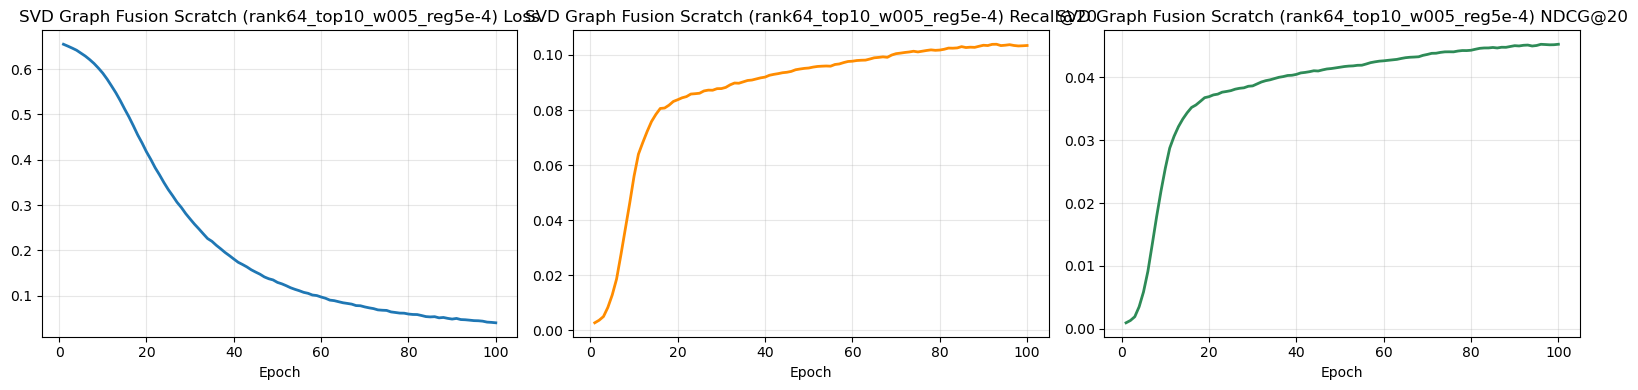

In [27]:
set_global_seed(SEED)
print_section('Training SVD Graph Fusion From Scratch')

# SVD uses rating-scaled interactions to recover global collaborative structure.
def build_weighted_interaction_matrix(train_df, n_users, n_items):
    values = np.clip((train_df['rating'].to_numpy(dtype=np.float32) - 1.0) / 4.0, 0.0, 1.0)
    return sp.csr_matrix((values, (train_df['user_idx'], train_df['item_idx'])), shape=(n_users, n_items))

def compute_svd_factors(interaction_matrix, latent_dim=128):
    latent_dim = min(latent_dim, max(1, min(interaction_matrix.shape) - 1))
    u, singular_values, vt = svds(interaction_matrix, k=latent_dim)
    sort_idx = np.argsort(singular_values)[::-1]
    singular_values, u, vt = singular_values[sort_idx], u[:, sort_idx], vt[sort_idx, :]
    singular_sqrt = np.sqrt(np.clip(singular_values, 1e-8, None)).astype(np.float32)
    return (u * singular_sqrt.reshape(1, -1)).astype(np.float32), (vt.T * singular_sqrt.reshape(1, -1)).astype(np.float32)

# For each user, add only the strongest unseen SVD-predicted items as soft graph edges.
def build_svd_global_edges(user_factors, item_factors, observed_items_map, top_k=20, batch_users=512):
    global_user_indices, global_item_indices, global_weights = [], [], []
    item_factor_matrix = item_factors.T.astype(np.float32)
    for start in range(0, user_factors.shape[0], batch_users):
        end = min(start + batch_users, user_factors.shape[0])
        batch_scores = np.matmul(user_factors[start:end], item_factor_matrix)
        for offset, user_idx in enumerate(range(start, end)):
            scores = batch_scores[offset].copy()
            seen_items = observed_items_map.get(int(user_idx), set())
            if seen_items:
                scores[np.fromiter(seen_items, dtype=np.int64)] = -1e9
            k = min(top_k, scores.shape[0])
            top_items = np.argpartition(scores, -k)[-k:]
            top_scores = scores[top_items]
            order = np.argsort(top_scores)[::-1]
            for item_idx, score in zip(top_items[order], top_scores[order]):
                global_user_indices.append(int(user_idx))
                global_item_indices.append(int(item_idx))
                global_weights.append(float(1.0 / (1.0 + np.exp(-score))))
    return np.asarray(global_user_indices), np.asarray(global_item_indices), np.asarray(global_weights, dtype=np.float32)

# Fuse original observed edges with weighted SVD edges, then normalize for LightGCN propagation.
def build_fused_graph_adj(train_df, n_users, n_items, global_user_indices, global_item_indices, global_weights, global_weight_scale=0.2):
    local_user_indices = train_df['user_idx'].to_numpy(dtype=np.int64)
    local_item_indices = train_df['item_idx'].to_numpy(dtype=np.int64)
    fused_user_indices = np.concatenate([local_user_indices, global_user_indices])
    fused_item_indices = np.concatenate([local_item_indices, global_item_indices])
    fused_weights = np.concatenate([np.ones(len(train_df), dtype=np.float32), global_weight_scale * global_weights])
    row = np.concatenate([fused_user_indices, fused_item_indices + n_users])
    col = np.concatenate([fused_item_indices + n_users, fused_user_indices])
    data = np.concatenate([fused_weights, fused_weights]).astype(np.float32)
    adj = sp.coo_matrix((data, (row, col)), shape=(n_users + n_items, n_users + n_items))
    rowsum = np.asarray(adj.sum(axis=1)).reshape(-1)
    d_inv = np.zeros_like(rowsum, dtype=np.float32)
    np.power(rowsum, -0.5, out=d_inv, where=rowsum > 0)
    norm_adj = sp.diags(d_inv).dot(adj).dot(sp.diags(d_inv)).tocoo()
    return torch.sparse_coo_tensor(torch.LongTensor(np.vstack([norm_adj.row, norm_adj.col])), torch.FloatTensor(norm_adj.data), torch.Size(norm_adj.shape)).coalesce().to(device)

fusion_cfg = MODEL_CONFIGS['svd_graph_fusion']
base_fusion_cfg = {k: v for k, v in fusion_cfg.items() if k != 'variants'}
if fusion_cfg.get('variants'):
    base_fusion_cfg = _merge_dict(base_fusion_cfg, fusion_cfg['variants'][0])
base_fusion_cfg.setdefault('name', 'fixed')
interaction_matrix = build_weighted_interaction_matrix(train_df, n_users, n_items)
svd_factor_cache = {}
svd_edge_cache = {}
svd_adj_cache = {}

def get_svd_fused_adj(cfg):
    latent_dim = int(cfg['latent_dim'])
    top_k_global = int(cfg['top_k_global'])
    global_weight_scale = float(cfg['global_weight_scale'])
    if latent_dim not in svd_factor_cache:
        svd_factor_cache[latent_dim] = compute_svd_factors(interaction_matrix, latent_dim=latent_dim)
    edge_key = (latent_dim, top_k_global)
    if edge_key not in svd_edge_cache:
        user_factors, item_factors = svd_factor_cache[latent_dim]
        svd_edge_cache[edge_key] = build_svd_global_edges(user_factors, item_factors, user_positive_items, top_k=top_k_global)
    adj_key = (latent_dim, top_k_global, global_weight_scale)
    if adj_key not in svd_adj_cache:
        global_u, global_i, global_w = svd_edge_cache[edge_key]
        svd_adj_cache[adj_key] = build_fused_graph_adj(train_df, n_users, n_items, global_u, global_i, global_w, global_weight_scale=global_weight_scale)
    return svd_adj_cache[adj_key]

# Train SVD Graph Fusion from scratch on the fused graph and select by validation NDCG.
def run_svd_fusion_trials():
    trials = get_grid_trials('svd_graph_fusion', base_fusion_cfg)
    trial_rows = []
    best_trial = None
    for trial in trials:
        trial_name, cfg = trial['name'], trial['config']
        if trial_name == 'fixed' and cfg.get('name'):
            trial_name = str(cfg['name'])
        print_section(f"SVD Graph Fusion From Scratch Trial: {trial_name}")
        set_global_seed(SEED + trial['index'] - 1)
        fused_adj = get_svd_fused_adj(cfg)
        model = LightGCN(
            n_users,
            n_items,
            embedding_dim=cfg.get('embedding_dim', lightgcn_cfg['embedding_dim']),
            n_layers=cfg.get('n_layers', lightgcn_cfg['n_layers']),
        ).to(device)
        save_path = model_dir / f"{dataset_slug}_svd_graph_fusion_scratch_{_sanitize_trial_name(trial_name)}.pth"
        train_start = time.time()
        history = train_lightgcn_with_val(
            model,
            fused_adj,
            train_df,
            val_df,
            {'lr': cfg['lr'], 'batch_size': cfg['batch_size'], 'reg_weight': cfg['reg_weight']},
            save_path,
        )
        train_time = time.time() - train_start
        model.load_state_dict(torch.load(save_path, map_location=device))
        val_metrics = evaluate_lightgcn(model, fused_adj, val_df, top_k=TOP_K)
        best_epoch, hist_best_ndcg, hist_best_recall = best_values_from_history(history)
        select_ndcg = hist_best_ndcg if history else val_metrics[f'NDCG@{TOP_K}']
        select_recall = hist_best_recall if history else val_metrics[f'Recall@{TOP_K}']
        row = {
            'Model': 'SVD Graph Fusion Scratch',
            'Trial': trial_name,
            f'ValNDCG@{TOP_K}': float(select_ndcg),
            f'ValRecall@{TOP_K}': float(select_recall),
            'BestEpoch': best_epoch,
            'EpochsRan': len(history),
            'TrainingTimeSec': train_time,
            'Checkpoint': str(save_path),
            'Config': cfg,
        }
        trial_rows.append(row)
        if GRID_SEARCH_ENABLED:
            grid_search_rows.append(row)
        if best_trial is None or (select_ndcg, select_recall) > (best_trial['select_ndcg'], best_trial['select_recall']):
            best_trial = {
                'model': model,
                'adj': fused_adj,
                'history': history,
                'train_time': train_time,
                'trial_name': trial_name,
                'config': cfg,
                'save_path': save_path,
                'select_ndcg': float(select_ndcg),
                'select_recall': float(select_recall),
                'trial_rows': trial_rows,
            }
    if trial_rows:
        print('SVD Graph Fusion trial summary:')
        display(pd.DataFrame([{k: v for k, v in row.items() if k != 'Config'} for row in trial_rows]).sort_values([f'ValNDCG@{TOP_K}', f'ValRecall@{TOP_K}'], ascending=[False, False]))
    return best_trial

graph_fusion_best = run_svd_fusion_trials()
best_graph_fusion_model = graph_fusion_best['model']
best_graph_fusion_adj = graph_fusion_best['adj']
best_graph_fusion_name = graph_fusion_best['trial_name']
best_graph_fusion_metrics = evaluate_lightgcn(best_graph_fusion_model, best_graph_fusion_adj, test_df, top_k=TOP_K)

# Replace any previous SVD Graph Fusion row if this cell is rerun in the same kernel.
final_results[:] = [row for row in final_results if not str(row.get('Model', '')).startswith('SVD Graph Fusion')]
training_summary_rows[:] = [row for row in training_summary_rows if not str(row.get('Model', '')).startswith('SVD Graph Fusion')]
record_training_summary(
    'SVD Graph Fusion Scratch',
    graph_fusion_best['history'],
    graph_fusion_best['train_time'],
    loaded_from_checkpoint=False,
    selected_trial=best_graph_fusion_name,
)
append_result('SVD Graph Fusion Scratch', best_graph_fusion_metrics)
display(pd.DataFrame([{'Model': 'SVD Graph Fusion Scratch', 'SelectedTrial': best_graph_fusion_name, **best_graph_fusion_metrics}]))
plot_history(graph_fusion_best['history'], f"SVD Graph Fusion Scratch ({best_graph_fusion_name})")


<a id='section-7-final-comparison'></a>
##### 7. Final Comparison



Final Comparison
Effectiveness metrics:


,Model,SelectedTrial,NDCG@20,Recall@20,Precision@20,MRR,num_users
2,SVD Graph Fusion Scratch,rank64_top10_w005_reg5e-4,0.033291,0.072619,0.004502,0.024596,15093
0,LightGCN BPR,emb128_l3_lr1e-3_reg1e-4,0.031780,0.070845,0.004436,0.023053,15093
1,LightGCL,fixed_n2_r5_tau05_cl02,0.031511,0.067309,0.004191,0.023749,15093
5,MLP Two Tower BPR,emb128_h256-128_lr1e-3_reg1e-4,0.027179,0.052447,0.003217,0.022382,15093
3,GraphSAGE,emb256_h256_l2_drop02_lr5e-4,0.027151,0.050161,0.003111,0.022901,15093
4,GATv2,emb128_l2_h4_lr5e-4_drop0,0.022307,0.045768,0.002885,0.017188,15093


Training efficiency and early stopping:


,Model,SelectedTrial,EpochsRan,BestEpoch,BestValNDCG@20,BestValRecall@20,EarlyStopped,TrainingTimeSec,LoadedFromCheckpoint,Skipped
0,LightGCN BPR,emb128_l3_lr1e-3_reg1e-4,43,33,0.045399,0.103117,True,652.539867,False,False
1,LightGCL,fixed_n2_r5_tau05_cl02,95,85,0.041119,0.092430,True,909.213701,False,False
2,SVD Graph Fusion Scratch,rank64_top10_w005_reg5e-4,100,100,0.045283,0.103427,False,1438.658766,False,False
3,GraphSAGE,emb256_h256_l2_drop02_lr5e-4,19,9,0.027332,0.058521,True,258.646044,False,False
4,GATv2,emb128_l2_h4_lr5e-4_drop0,22,12,0.023921,0.053372,True,249.507937,False,False
5,MLP Two Tower BPR,emb128_h256-128_lr1e-3_reg1e-4,13,3,0.027447,0.061095,True,333.106931,False,False


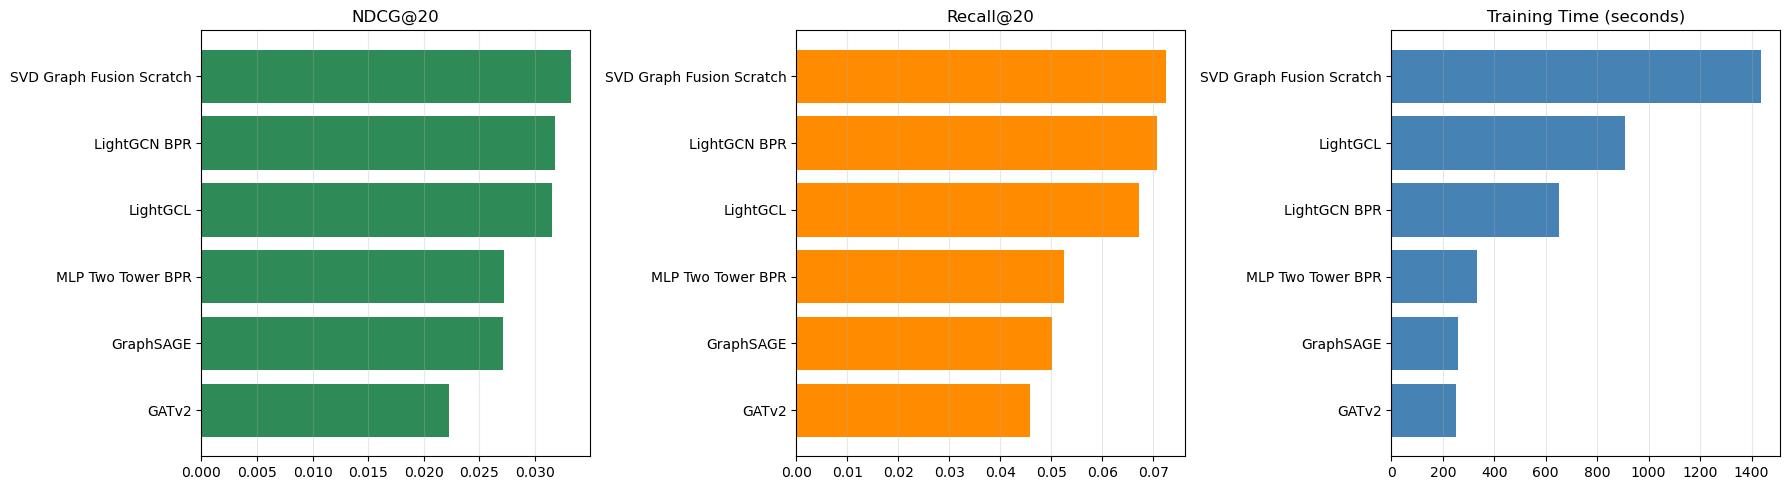

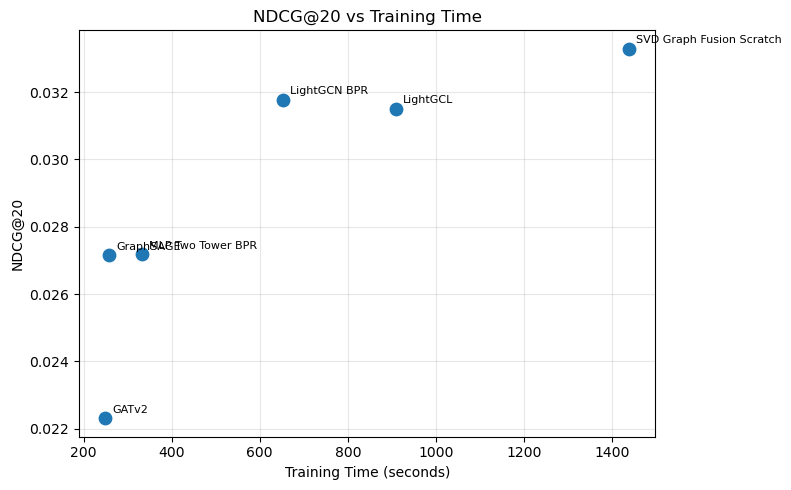

In [36]:
print_section('Final Comparison')

# Combine test metrics with training-time summaries for the final model table.
final_comparison_df = pd.DataFrame(final_results)
training_summary_df = pd.DataFrame(training_summary_rows)
comparison_with_runtime_df = final_comparison_df.merge(training_summary_df, on='Model', how='left')

effectiveness_cols = ['Model', 'SelectedTrial', f'NDCG@{TOP_K}', f'Recall@{TOP_K}', f'Precision@{TOP_K}', 'MRR', 'num_users']
runtime_cols = [
    'Model', 'SelectedTrial', 'EpochsRan', 'BestEpoch', f'BestValNDCG@{TOP_K}', f'BestValRecall@{TOP_K}',
    'EarlyStopped', 'TrainingTimeSec', 'LoadedFromCheckpoint', 'Skipped'
]

if grid_search_rows:
    print('Grid search trials:')
    grid_search_df = pd.DataFrame([{k: v for k, v in row.items() if k != 'Config'} for row in grid_search_rows])
    display(grid_search_df.sort_values(['Model', f'ValNDCG@{TOP_K}', f'ValRecall@{TOP_K}'], ascending=[True, False, False]))

print('Effectiveness metrics:')
display(comparison_with_runtime_df[[col for col in effectiveness_cols if col in comparison_with_runtime_df.columns]].sort_values(f'NDCG@{TOP_K}', ascending=False))
print('Training efficiency and early stopping:')
display(comparison_with_runtime_df[[col for col in runtime_cols if col in comparison_with_runtime_df.columns]])

# Side-by-side bars make effectiveness and runtime tradeoffs easy to compare.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_df = comparison_with_runtime_df.sort_values(f'NDCG@{TOP_K}', ascending=True)
axes[0].barh(plot_df['Model'], plot_df[f'NDCG@{TOP_K}'], color='seagreen')
axes[0].set_title(f'NDCG@{TOP_K}')
axes[0].grid(axis='x', alpha=0.3)

plot_df = comparison_with_runtime_df.sort_values(f'Recall@{TOP_K}', ascending=True)
axes[1].barh(plot_df['Model'], plot_df[f'Recall@{TOP_K}'], color='darkorange')
axes[1].set_title(f'Recall@{TOP_K}')
axes[1].grid(axis='x', alpha=0.3)

plot_df = comparison_with_runtime_df.sort_values('TrainingTimeSec', ascending=True)
axes[2].barh(plot_df['Model'], plot_df['TrainingTimeSec'], color='steelblue')
axes[2].set_title('Training Time (seconds)')
axes[2].grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(comparison_with_runtime_df['TrainingTimeSec'], comparison_with_runtime_df[f'NDCG@{TOP_K}'], s=80)
for _, row in comparison_with_runtime_df.iterrows():
    ax.annotate(row['Model'], (row['TrainingTimeSec'], row[f'NDCG@{TOP_K}']), fontsize=8, xytext=(5, 4), textcoords='offset points')
ax.set_xlabel('Training Time (seconds)')
ax.set_ylabel(f'NDCG@{TOP_K}')
ax.set_title(f'NDCG@{TOP_K} vs Training Time')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


<a id='section-8-model-behavior-analysis'></a>
##### 8. Model Behavior Analysis



Model Behavior Analysis
Available models for behavior analysis: ['MLP Two Tower BPR', 'LightGCN BPR', 'LightGCL', 'GATv2', 'GraphSAGE', 'SVD Graph Fusion Scratch']


,Model,user_idx,rank,item_idx,score,is_hit,item_popularity,item_avg_rating,num_relevant_items
0,MLP Two Tower BPR,0,1,5719,3.716214,0,238,4.794118,1
1,MLP Two Tower BPR,0,2,1188,3.626893,0,191,4.743455,1
2,MLP Two Tower BPR,0,3,3759,3.569153,0,97,4.680412,1
3,MLP Two Tower BPR,0,4,345,3.425128,0,150,4.413333,1
4,MLP Two Tower BPR,0,5,649,3.402207,0,261,4.708812,1


,Model,NDCG@20,Recall@20,HitRateAt20,AvgUserRecallAt20,CatalogCoverage,AvgRecommendedPopularity,AvgRecommendedRating,AvgFirstHitRank
5,SVD Graph Fusion Scratch,0.033291,0.072619,0.086861,0.072619,0.660293,71.753833,4.667199,8.028986
3,LightGCN BPR,0.031780,0.070845,0.085470,0.070845,0.749690,61.101067,4.653431,8.206977
2,LightGCL,0.031511,0.067309,0.081230,0.067309,0.605910,60.566720,4.654030,7.765090
4,MLP Two Tower BPR,0.027179,0.052447,0.063142,0.052447,0.003601,121.905476,4.684786,7.974816
1,GraphSAGE,0.027151,0.050161,0.061088,0.050161,0.139310,118.750139,4.665445,7.327549
0,GATv2,0.022307,0.045768,0.056384,0.045768,0.013285,104.363380,4.686681,6.564042


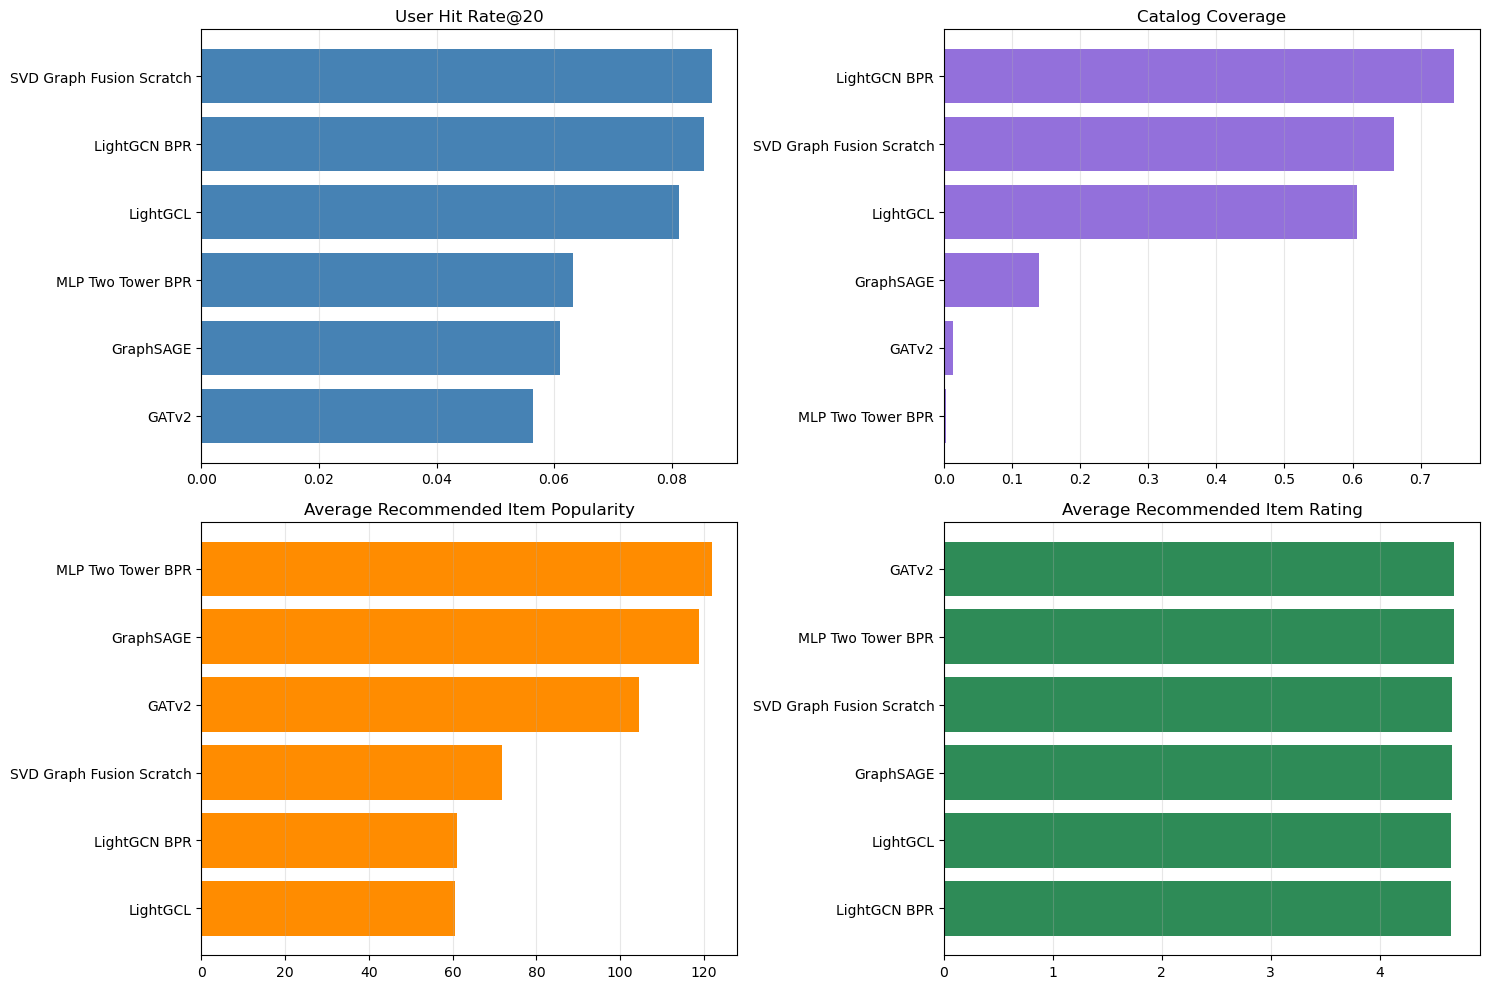

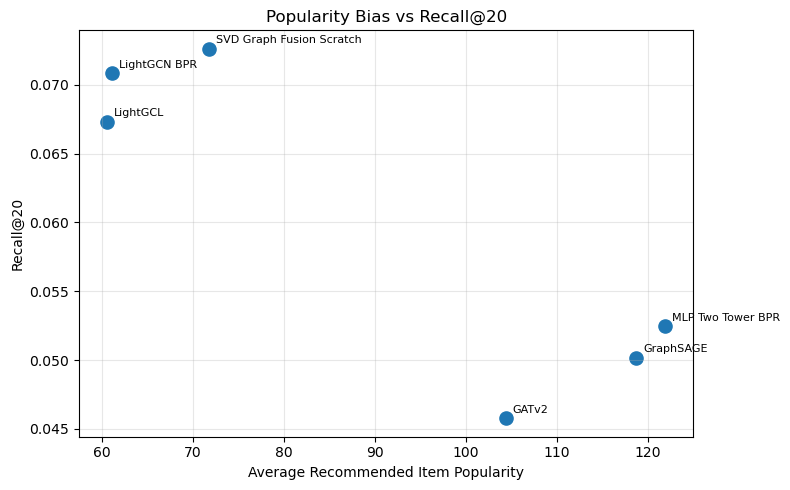

,Model,user_idx,rank,item_idx,score,item_popularity,item_avg_rating
915320,GATv2,487,1,649,6.163030,261,4.708812
917100,GATv2,576,1,649,10.971431,261,4.708812
919500,GATv2,696,1,649,7.036623,261,4.708812
939520,GATv2,1697,1,649,7.273747,261,4.708812
939540,GATv2,1698,1,5719,11.323915,238,4.794118
1216320,GraphSAGE,444,1,5719,6.204393,238,4.794118
1216920,GraphSAGE,474,1,5719,8.838947,238,4.794118
1217380,GraphSAGE,497,1,5719,7.317215,238,4.794118
1217680,GraphSAGE,512,1,5719,12.741348,238,4.794118
1218880,GraphSAGE,572,1,5719,9.819779,238,4.794118


In [37]:
print_section('Model Behavior Analysis')

ANALYSIS_MAX_USERS = None if n_users <= 50000 else 5000
ANALYSIS_RANDOM_SEED = SEED

def _sample_analysis_users(eval_df, max_users=None):
    relevant_by_user = _group_relevant_items(eval_df, RELEVANCE_THRESHOLD)
    users = np.array(sorted(relevant_by_user.keys()), dtype=np.int64)
    if max_users is not None and len(users) > max_users:
        rng = np.random.default_rng(ANALYSIS_RANDOM_SEED)
        users = np.sort(rng.choice(users, size=max_users, replace=False))
    return users, relevant_by_user

def _build_behavior_score_functions():
    score_functions = {}
    all_items_tensor = torch.arange(n_items, device=device)

    if 'two_tower_bpr_model' in globals():
        two_tower_bpr_model.eval()
        score_functions['MLP Two Tower BPR'] = lambda user_idx: _score_two_tower_all_items(two_tower_bpr_model, user_idx, all_items_tensor)

    if 'lightgcn_bpr_model' in globals():
        lightgcn_bpr_model.eval()
        with torch.no_grad():
            lgcn_user_emb, lgcn_item_emb = lightgcn_bpr_model.computer(norm_adj_tensor)
        def score_lightgcn(user_idx):
            raw_scores = (lgcn_user_emb[user_idx].unsqueeze(0) * lgcn_item_emb).sum(dim=1)
            users_batch = torch.full((n_items,), int(user_idx), dtype=torch.long, device=device)
            return lightgcn_bpr_model._apply_rating_head(raw_scores, users_batch, all_items_tensor, apply_range=True)
        score_functions['LightGCN BPR'] = score_lightgcn

    if 'lightgcl_model' in globals():
        lightgcl_model.eval()
        with torch.no_grad():
            lightgcl_user_emb, lightgcl_item_emb, *_ = lightgcl_model.propagate(norm_adj_tensor)
        score_functions['LightGCL'] = lambda user_idx: lightgcl_user_emb[user_idx] @ lightgcl_item_emb.t()

    if 'gat_model' in globals() and globals().get('gat_metrics') is not None and 'edge_index' in globals():
        gat_model.eval()
        with torch.no_grad():
            gat_user_emb, gat_item_emb = gat_model.propagate(edge_index)
        score_functions['GATv2'] = lambda user_idx: gat_user_emb[user_idx] @ gat_item_emb.t()

    if 'graphsage_model' in globals():
        graphsage_model.eval()
        with torch.no_grad():
            sage_user_emb, sage_item_emb = graphsage_model.get_all_embeddings(norm_adj_tensor)
        def score_graphsage(user_idx):
            user_tensor = torch.LongTensor([user_idx]).to(device)
            scores = torch.matmul(sage_item_emb, sage_user_emb[user_idx])
            scores = scores + graphsage_model.item_bias(all_items_tensor).squeeze(-1)
            scores = scores + graphsage_model.user_bias(user_tensor).squeeze(-1)
            scores = scores + graphsage_model.global_bias
            return scores
        score_functions['GraphSAGE'] = score_graphsage

    if 'best_graph_fusion_model' in globals() and 'best_graph_fusion_adj' in globals():
        best_graph_fusion_model.eval()
        with torch.no_grad():
            fusion_user_emb, fusion_item_emb = best_graph_fusion_model.computer(best_graph_fusion_adj)
        def score_fusion(user_idx):
            raw_scores = (fusion_user_emb[user_idx].unsqueeze(0) * fusion_item_emb).sum(dim=1)
            users_batch = torch.full((n_items,), int(user_idx), dtype=torch.long, device=device)
            return best_graph_fusion_model._apply_rating_head(raw_scores, users_batch, all_items_tensor, apply_range=True)
        score_functions['SVD Graph Fusion Scratch'] = score_fusion

    return score_functions

# Materialize top-K recommendations so we can analyze hits, popularity, and coverage.
def collect_topk_recommendations(score_functions, eval_df, top_k=TOP_K, max_users=ANALYSIS_MAX_USERS):
    users, relevant_by_user = _sample_analysis_users(eval_df, max_users=max_users)
    item_popularity = train_df.groupby('item_idx').size().to_dict()
    item_avg_rating = train_df.groupby('item_idx')['rating'].mean().to_dict()
    global_avg_rating = float(train_df['rating'].mean())
    rows = []

    for model_name, score_fn in score_functions.items():
        print(f'Collecting Top-{top_k} recommendations for {model_name} on {len(users):,} users...')
        for user_idx in users:
            relevant_items = relevant_by_user.get(int(user_idx), set())
            if not relevant_items:
                continue
            scores = score_fn(int(user_idx)).detach().clone()
            seen_items = list(user_positive_items.get(int(user_idx), set()))
            if seen_items:
                scores[seen_items] = -1e9
            top_scores, top_items = torch.topk(scores, k=min(top_k, scores.numel()))
            for rank, (item_idx, score_value) in enumerate(zip(top_items.cpu().numpy(), top_scores.cpu().numpy()), start=1):
                item_idx = int(item_idx)
                rows.append({
                    'Model': model_name,
                    'user_idx': int(user_idx),
                    'rank': rank,
                    'item_idx': item_idx,
                    'score': float(score_value),
                    'is_hit': int(item_idx in relevant_items),
                    'item_popularity': int(item_popularity.get(item_idx, 0)),
                    'item_avg_rating': float(item_avg_rating.get(item_idx, global_avg_rating)),
                    'num_relevant_items': len(relevant_items),
                })
    return pd.DataFrame(rows)

behavior_score_functions = _build_behavior_score_functions()
print(f'Available models for behavior analysis: {list(behavior_score_functions.keys())}')
topk_recommendations_df = collect_topk_recommendations(behavior_score_functions, test_df, top_k=TOP_K, max_users=ANALYSIS_MAX_USERS)
display(topk_recommendations_df.head())

if topk_recommendations_df.empty:
    print('No recommendations collected. Run the model sections first, then rerun this section.')
else:
    per_user_behavior_df = topk_recommendations_df.groupby(['Model', 'user_idx'], as_index=False).agg(
        hits=('is_hit', 'sum'),
        num_relevant_items=('num_relevant_items', 'first'),
    )
    first_hit_rank_df = (
        topk_recommendations_df[topk_recommendations_df['is_hit'] == 1]
        .groupby(['Model', 'user_idx'], as_index=False)['rank']
        .min()
        .rename(columns={'rank': 'AvgFirstHitRank'})
    )
    per_user_behavior_df = per_user_behavior_df.merge(first_hit_rank_df, on=['Model', 'user_idx'], how='left')
    per_user_behavior_df[f'Recall@{TOP_K}'] = per_user_behavior_df['hits'] / per_user_behavior_df['num_relevant_items']

    behavior_summary_df = topk_recommendations_df.groupby('Model').agg(
        AvgRecommendedPopularity=('item_popularity', 'mean'),
        MedianRecommendedPopularity=('item_popularity', 'median'),
        AvgRecommendedRating=('item_avg_rating', 'mean'),
        CatalogCoverage=('item_idx', lambda x: x.nunique() / n_items),
    ).reset_index()
    user_hit_summary = per_user_behavior_df.groupby('Model').agg(
        HitRateAt20=('hits', lambda x: float((x > 0).mean())),
        AvgUserRecallAt20=(f'Recall@{TOP_K}', 'mean'),
        AvgFirstHitRank=('AvgFirstHitRank', 'mean'),
    ).reset_index()
    behavior_summary_df = behavior_summary_df.merge(user_hit_summary, on='Model', how='left')

    behavior_report_df = behavior_summary_df
    if 'final_comparison_df' in globals():
        behavior_report_df = behavior_report_df.merge(
            final_comparison_df[['Model', f'NDCG@{TOP_K}', f'Recall@{TOP_K}']],
            on='Model',
            how='left',
        )

    behavior_cols = [
        'Model', f'NDCG@{TOP_K}', f'Recall@{TOP_K}', 'HitRateAt20', 'AvgUserRecallAt20',
        'CatalogCoverage', 'AvgRecommendedPopularity', 'AvgRecommendedRating', 'AvgFirstHitRank'
    ]
    behavior_sort_col = f'Recall@{TOP_K}' if f'Recall@{TOP_K}' in behavior_report_df.columns else 'AvgUserRecallAt20'
    display(behavior_report_df[[col for col in behavior_cols if col in behavior_report_df.columns]].sort_values(behavior_sort_col, ascending=False))

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    plot_df = behavior_report_df.sort_values('HitRateAt20', ascending=True)
    axes[0, 0].barh(plot_df['Model'], plot_df['HitRateAt20'], color='steelblue')
    axes[0, 0].set_title(f'User Hit Rate@{TOP_K}')
    axes[0, 0].grid(axis='x', alpha=0.3)

    plot_df = behavior_report_df.sort_values('CatalogCoverage', ascending=True)
    axes[0, 1].barh(plot_df['Model'], plot_df['CatalogCoverage'], color='mediumpurple')
    axes[0, 1].set_title('Catalog Coverage')
    axes[0, 1].grid(axis='x', alpha=0.3)

    plot_df = behavior_report_df.sort_values('AvgRecommendedPopularity', ascending=True)
    axes[1, 0].barh(plot_df['Model'], plot_df['AvgRecommendedPopularity'], color='darkorange')
    axes[1, 0].set_title('Average Recommended Item Popularity')
    axes[1, 0].grid(axis='x', alpha=0.3)

    plot_df = behavior_report_df.sort_values('AvgRecommendedRating', ascending=True)
    axes[1, 1].barh(plot_df['Model'], plot_df['AvgRecommendedRating'], color='seagreen')
    axes[1, 1].set_title('Average Recommended Item Rating')
    axes[1, 1].grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 5))
    scatter_y_col = f'Recall@{TOP_K}' if f'Recall@{TOP_K}' in behavior_report_df.columns else 'AvgUserRecallAt20'
    ax.scatter(behavior_report_df['AvgRecommendedPopularity'], behavior_report_df[scatter_y_col], s=90)
    for _, row in behavior_report_df.iterrows():
        ax.annotate(row['Model'], (row['AvgRecommendedPopularity'], row[scatter_y_col]), fontsize=8, xytext=(5, 4), textcoords='offset points')
    ax.set_xlabel('Average Recommended Item Popularity')
    ax.set_ylabel(scatter_y_col)
    ax.set_title(f'Popularity Bias vs {scatter_y_col}')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    example_hits_df = topk_recommendations_df[topk_recommendations_df['is_hit'] == 1].sort_values(['Model', 'rank']).groupby('Model').head(5)
    display(example_hits_df[['Model', 'user_idx', 'rank', 'item_idx', 'score', 'item_popularity', 'item_avg_rating']])
